# 3C Summary — One-shot QC + Plots

This notebook is designed to be **run top-to-bottom** and then shared.

It will:
1) explain the expected input format
2) load all `*_summary.csv` in the 3C folder
3) show quick tables + QC plots (counts + CIS/TRANS composition)
4) (optionally) save plots to `Outputs/3C`

## Data location
This notebook reads from `WILSONTEW_3C_FOLDER` if set; otherwise it falls back to `./ThreeC_Data`.
Current recommended 3C folder (from your setup):
- `C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary`

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
})


## Expected columns (typical)
Most 3C summary CSVs include columns like:
- `batch`, `time_point`, `DSB`, `allele`, `combo`, `cis_trans`, `repeat`, `replicate`, `count`

This notebook filters to time points 0 and 120 by default (matches the existing 3C QC report).

In [2]:
# ---- Locate 3C folder ----
threec_folder <- Sys.getenv('WILSONTEW_3C_FOLDER', unset = file.path(getwd(), 'ThreeC_Data'))
threec_folder <- normalizePath(threec_folder, winslash = '/', mustWork = FALSE)
dir.create(threec_folder, recursive = TRUE, showWarnings = FALSE)
message('Using threec_folder: ', threec_folder)

files <- list.files(threec_folder, pattern = '_summary\\.csv$', full.names = TRUE)
if (length(files) == 0) {
  stop(paste0(
    'No *_summary.csv files found in threec_folder: ', threec_folder,
    '\n\nFix: set WILSONTEW_3C_FOLDER to the directory that contains your 3C summary CSVs.'
  ))
}
message('Found ', length(files), ' file(s).')
head(files, 10)

Using threec_folder: C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary

Found 8 file(s).



[1] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_2_3C_T0_final_summary.csv"  
[2] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_2_3C_T120_final_summary.csv"
[3] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_T0_3C_summary.csv"          
[4] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_T120_3C_summary.csv"        
[5] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch6_T0_3C_summary.csv"          
[6] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch6_T120_3C_summary.csv"        
[7] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch8_T0_3C_summary.csv"          
[8] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch8_T120_3C_summary.csv"

In [3]:
# ---- Read and combine ----
# Some 3C summary CSVs include extra columns whose types vary across runs (e.g., *_loci).
# To keep binding robust, read everything as character, then parse only the columns we need.
read_one <- function(f) {
  dat <- readr::read_csv(
    f,
    show_col_types = FALSE,
    col_types = readr::cols(.default = readr::col_character())
  )
  if (!("repeat" %in% names(dat))) dat <- dplyr::mutate(dat, `repeat` = "ALL")
  if (!("replicate" %in% names(dat))) dat <- dplyr::mutate(dat, replicate = "ALL")
  
  # Parse key columns if present
  if ("count" %in% names(dat)) dat$count <- readr::parse_double(dat$count)
  if ("time_point" %in% names(dat)) dat$time_point <- readr::parse_number(dat$time_point)
  if ("replicate" %in% names(dat)) dat$replicate <- as.character(dat$replicate)
  
  dat <- dplyr::mutate(
    dat,
    source_path = f,
    source_dir = dirname(f),
    allele = as.character(.data[["allele"]]),
    combo = as.character(.data[["combo"]]),
    cis_trans = as.character(.data[["cis_trans"]]),
    DSB = as.character(.data[["DSB"]]),
    `repeat` = as.character(.data[["repeat"]]),
    replicate = as.character(.data[["replicate"]]),
    batch = as.character(.data[["batch"]])
  )
  dat
}

dat_raw <- purrr::map_dfr(files, read_one)
dat_raw <- dplyr::mutate(dat_raw, batch = factor(batch, levels = sort(unique(batch))))

# Match the 3C report convention: only 0 and 120 (edit if needed)
dat_raw <- dat_raw %>% filter(time_point %in% c(0, 120))

dplyr::glimpse(dat_raw)

Rows: 596
Columns: 13
$ batch          <fct> 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4…
$ DSB2_loci      <chr> "7", "7", "7", "7", "7", "7", "7", "7", "7", "7", "7", …
$ time_point     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ replicate      <chr> "2", "2", "2", "2", "2", "2", "2", "2", "2", "2", "2", …
$ alignment_name <chr> "CIS_A_to_B_DSB1_Chr12_L01", "CIS_A_to_B_DSB1_Chr12_L05…
$ cis_trans      <chr> "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS",…
$ DSB            <chr> "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1",…
$ combo          <chr> "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to…
$ allele         <chr> "Chr12_L01", "Chr12_L05", "Chr12_L07", "Chr12_L12", "Ch…
$ count          <dbl> 17041, 37724, 14131, 17156, 24218, 72, 17820, 20767, 26…
$ `repeat`       <chr> "ALL", "ALL", "ALL", "ALL", "ALL", "ALL", "ALL", "ALL",…
$ source_path    <chr> "C:/Users/dunnmk/University of Michigan Dropbox/MED-WIL…
$ source_dir     <

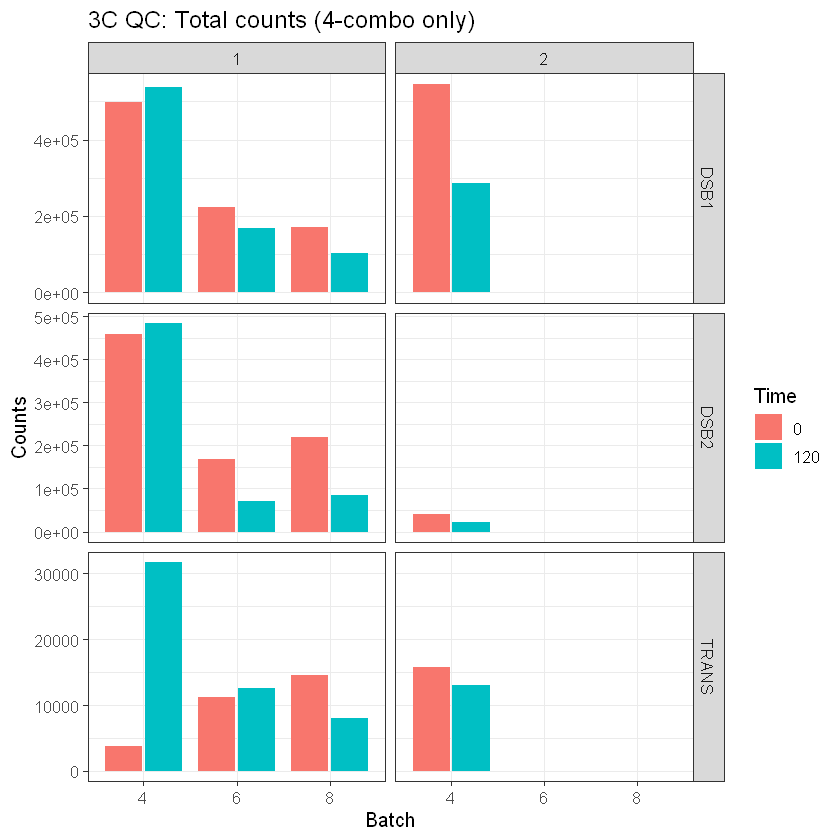

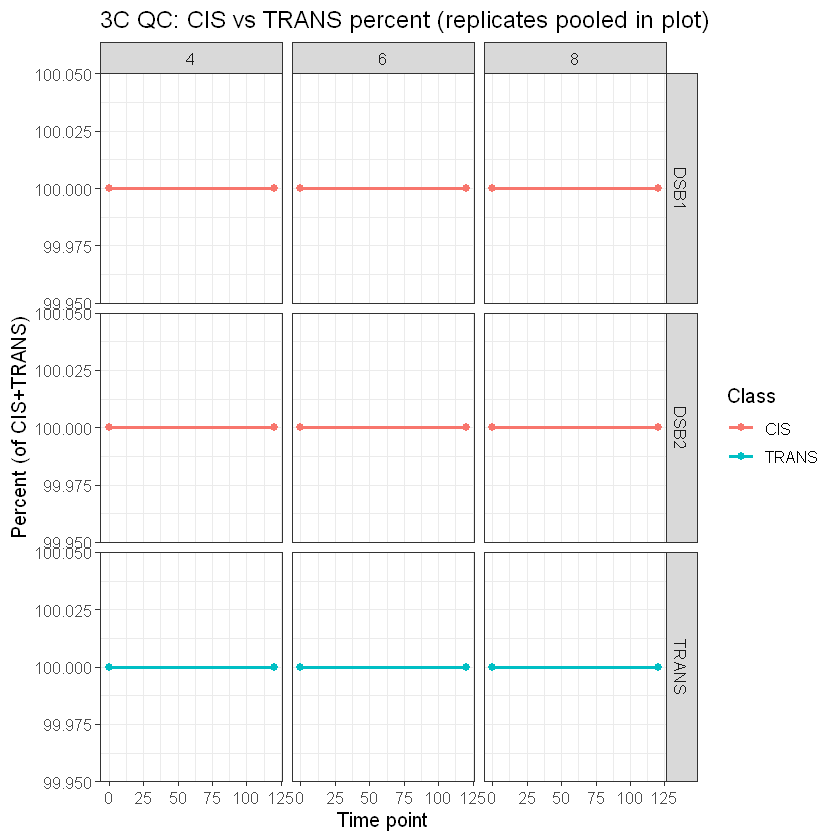

In [4]:
# ---- QC plots ----
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

dat4 <- dat_raw %>% filter(combo %in% combos_4)

qc_totals <- dat4 %>%
  group_by(batch, time_point, DSB, replicate) %>%
  summarise(Total_Counts = sum(count, na.rm = TRUE), .groups = 'drop')

p_total <- ggplot(qc_totals, aes(x = batch, y = Total_Counts, fill = factor(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.8) +
  facet_grid(DSB ~ replicate, scales = 'free_y') +
  theme_bw(base_size = 12) +
  labs(title = '3C QC: Total counts (4-combo only)', x = 'Batch', y = 'Counts', fill = 'Time')
print(p_total)

qc_cistrans <- dat4 %>%
  mutate(class = case_when(combo %in% cis_combos ~ 'CIS', combo %in% trans_combos ~ 'TRANS', TRUE ~ 'OTHER')) %>%
  group_by(batch, time_point, DSB, replicate, class) %>%
  summarise(Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(batch, time_point, DSB, replicate) %>%
  mutate(Percent = if_else(sum(Counts, na.rm = TRUE) > 0, 100 * Counts / sum(Counts, na.rm = TRUE), NA_real_)) %>%
  ungroup()

p_cistrans <- ggplot(qc_cistrans, aes(x = as.numeric(as.character(time_point)), y = Percent, color = class)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2) +
  facet_grid(DSB ~ batch) +
  theme_bw(base_size = 12) +
  labs(title = '3C QC: CIS vs TRANS percent (replicates pooled in plot)', x = 'Time point', y = 'Percent (of CIS+TRANS)', color = 'Class')
print(p_cistrans)

In [ ]:
# ---- Optional: save plots for sharing ----
out_dir <- file.path(getwd(), 'Outputs', '3C')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
ggsave(filename = file.path(out_dir, '3C_QC_total_counts.png'), plot = p_total, width = 14, height = 7, dpi = 200)
ggsave(filename = file.path(out_dir, '3C_QC_cis_trans_percent.png'), plot = p_cistrans, width = 14, height = 8, dpi = 200)
message('Saved plots to: ', out_dir)

Saved plots to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/3C



## Advanced analyses (Sections 4–9 from aggregate workflow)

The blocks below add:

- Group-level CIS/TRANS composition summaries
- Allele frequency and Pearson correlation (T0 vs T120)
- Fold-change and log2 fold-change metrics
- Correlations of log2FC vs allele frequency
- Per-allele contribution plots (CIS/TRANS + combo breakdown)
- Export of advanced plots and diagnostics

In [5]:
# ---- Helpers + guardrails ----
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

required_cols <- c('batch', 'time_point', 'DSB', 'allele', 'combo', 'cis_trans', 'count')
missing_cols <- setdiff(required_cols, names(dat_raw))
if (length(missing_cols) > 0) {
  stop(paste0('Missing required columns: ', paste(missing_cols, collapse = ', ')))
}

fc_ratio <- function(num, den, eps = 1e-6) {
  ifelse(
    is.na(num) | is.na(den),
    NA_real_,
    ifelse(num == 0 & den == 0, NA_real_, (num + eps) / (den + eps))
  )
}

has_ggrepel <- requireNamespace('ggrepel', quietly = TRUE)

dat_focus <- dat_raw %>%
  filter(combo %in% combos_4) %>%
  mutate(
    time_point = as.numeric(as.character(time_point)),
    batch = as.character(batch),
    DSB = as.character(DSB),
    allele = as.character(allele),
    combo = as.character(combo)
  )

if (nrow(dat_focus) == 0) {
  stop('No rows remain after filtering to 4-combo set (A_to_B, C_to_D, A_to_D, C_to_B).')
}

message('Rows in dat_focus: ', nrow(dat_focus))
message('Distinct alleles: ', dplyr::n_distinct(dat_focus$allele))
message('Distinct batches: ', dplyr::n_distinct(dat_focus$batch))

Rows in dat_focus: 596

Distinct alleles: 29

Distinct batches: 3



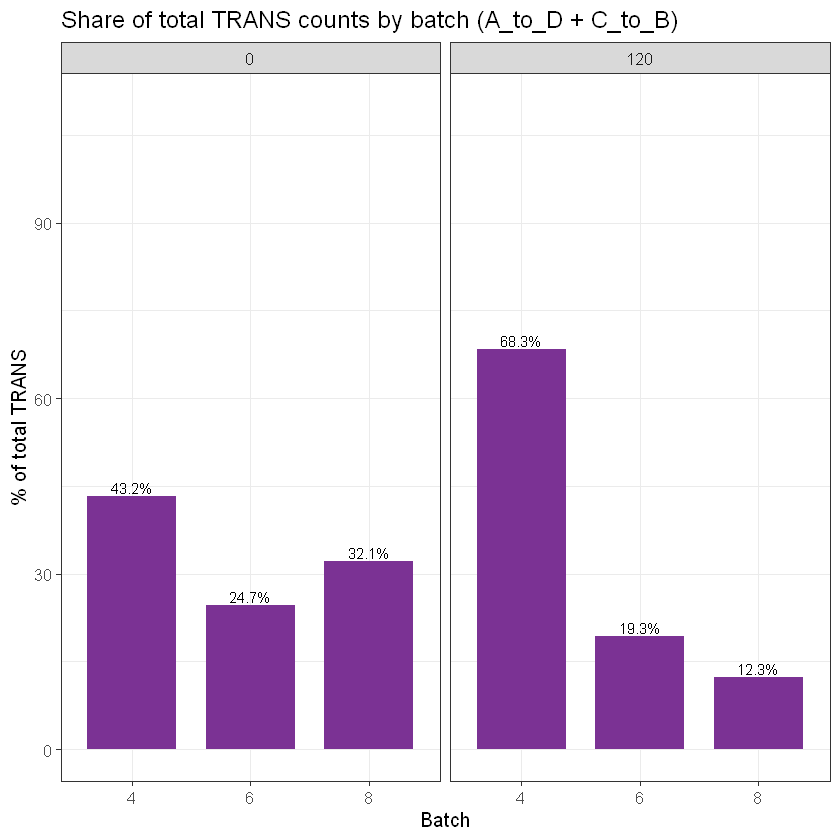

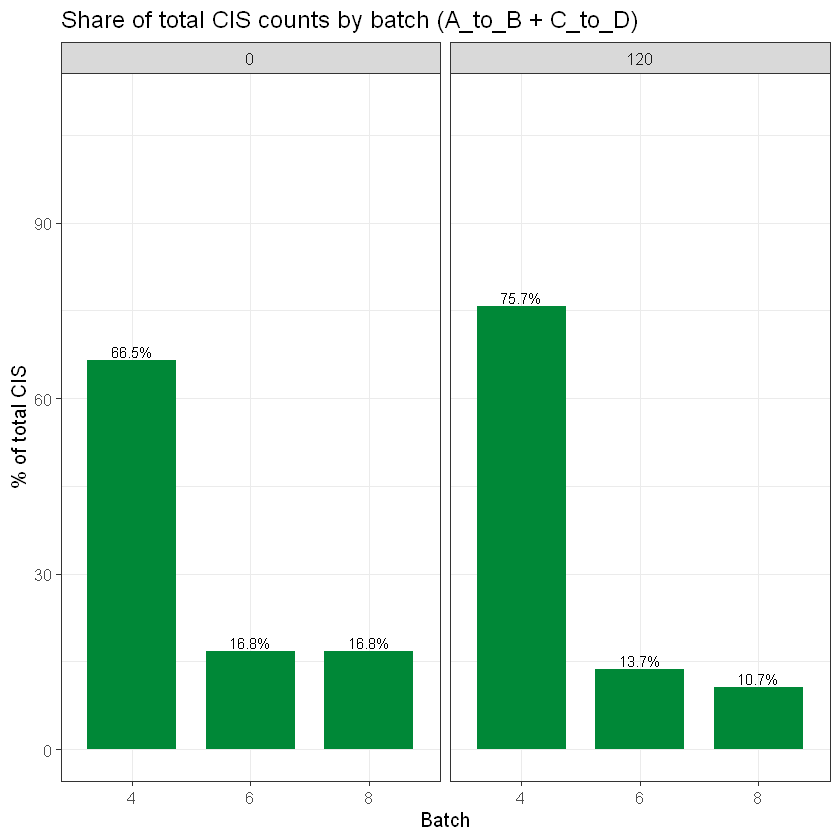

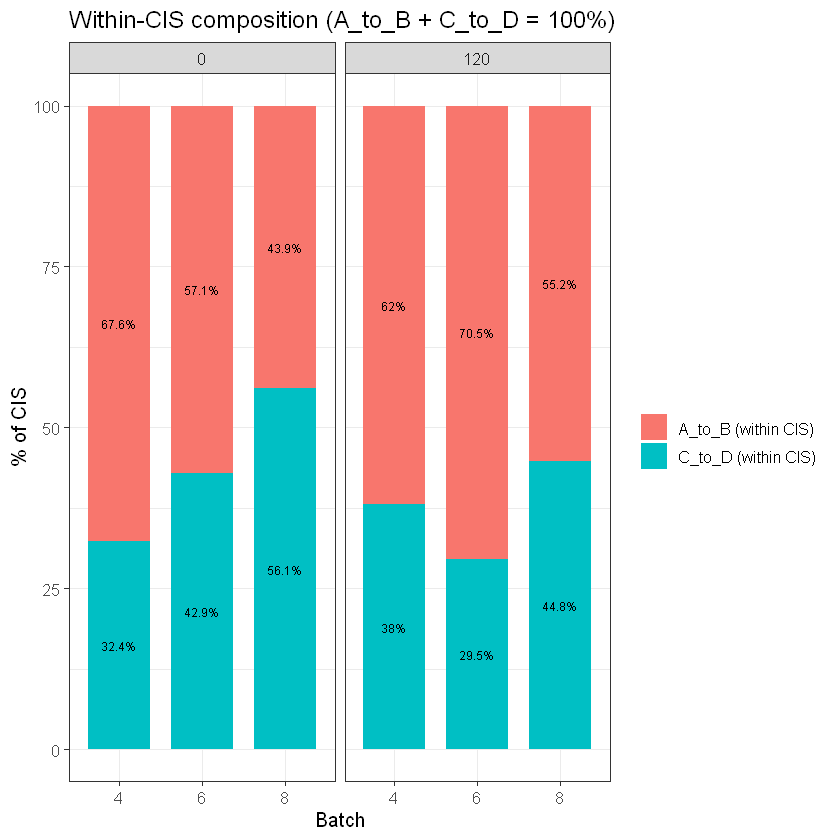

batch,time_point,DSB,allele,Cis_Location_Counts,Trans_Location_Counts,Total_Cis_Location_Counts,Total_Trans_Location_Counts,Total_Group_Counts,Percent_Cis_of_GroupTotal,Percent_Trans_of_GroupTotal,Percent_Location_in_Cis,Percent_Location_in_Trans
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,0,DSB1,Chr12_L01,40406,0,1045995,0,1045995,3.86292477,0,3.86292477,NA
4,0,DSB1,Chr12_L05,52843,0,1045995,0,1045995,5.05193619,0,5.05193619,NA
4,0,DSB1,Chr12_L07,33612,0,1045995,0,1045995,3.21339968,0,3.21339968,NA
4,0,DSB1,Chr12_L12,39935,0,1045995,0,1045995,3.81789588,0,3.81789588,NA
4,0,DSB1,Chr15_L01,52086,0,1045995,0,1045995,4.97956491,0,4.97956491,NA
4,0,DSB1,Chr15_L04,126,0,1045995,0,1045995,0.01204595,0,0.01204595,NA
4,0,DSB1,Chr15_L15,32276,0,1045995,0,1045995,3.08567441,0,3.08567441,NA
4,0,DSB1,Chr15_L17_2,49105,0,1045995,0,1045995,4.69457311,0,4.69457311,NA
4,0,DSB1,Chr15_L18,7293,0,1045995,0,1045995,0.69723087,0,0.69723087,NA


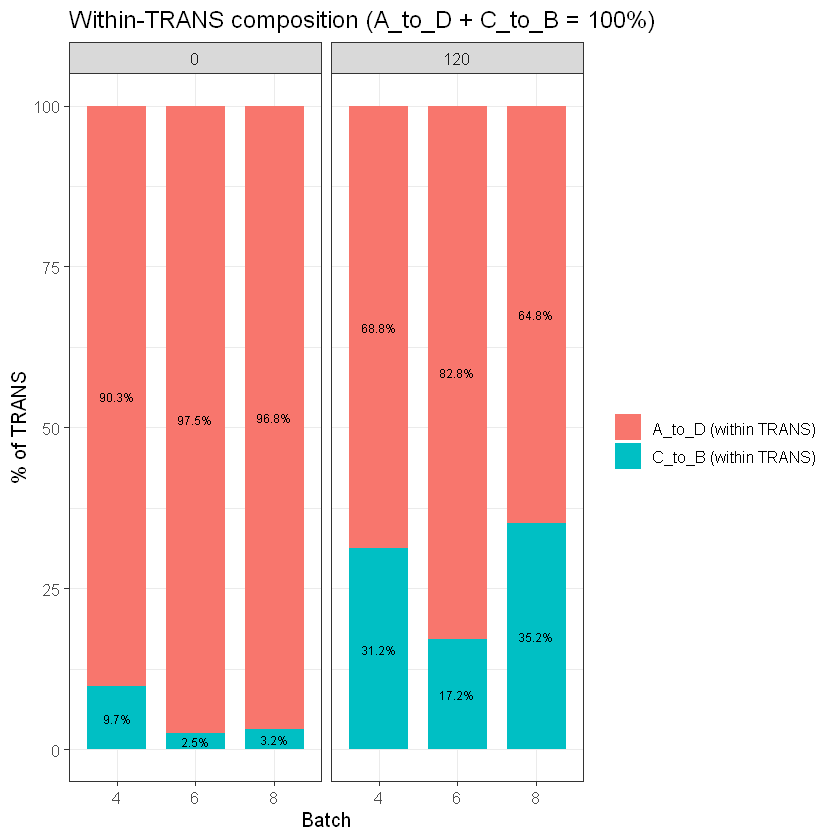

In [6]:
# ---- Section 4: group-level allele frequency summaries + composition plots ----
my_summarize_cistrans_by_combo <- function(dat, cis_combos, trans_combos, count_col = 'count') {
  by_allele <- dat %>%
    group_by(batch, time_point, DSB, allele) %>%
    summarise(
      Cis_Location_Counts = sum(.data[[count_col]][combo %in% cis_combos], na.rm = TRUE),
      Trans_Location_Counts = sum(.data[[count_col]][combo %in% trans_combos], na.rm = TRUE),
      .groups = 'drop'
    )

  totals <- by_allele %>%
    group_by(batch, time_point, DSB) %>%
    summarise(
      Total_Cis_Location_Counts = sum(Cis_Location_Counts, na.rm = TRUE),
      Total_Trans_Location_Counts = sum(Trans_Location_Counts, na.rm = TRUE),
      .groups = 'drop'
    )

  by_allele %>%
    left_join(totals, by = c('batch', 'time_point', 'DSB')) %>%
    mutate(
      Total_Group_Counts = Total_Cis_Location_Counts + Total_Trans_Location_Counts,
      Percent_Cis_of_GroupTotal = if_else(Total_Group_Counts > 0, 100 * Cis_Location_Counts / Total_Group_Counts, NA_real_),
      Percent_Trans_of_GroupTotal = if_else(Total_Group_Counts > 0, 100 * Trans_Location_Counts / Total_Group_Counts, NA_real_),
      Percent_Location_in_Cis = if_else(Total_Cis_Location_Counts > 0, 100 * Cis_Location_Counts / Total_Cis_Location_Counts, NA_real_),
      Percent_Location_in_Trans = if_else(Total_Trans_Location_Counts > 0, 100 * Trans_Location_Counts / Total_Trans_Location_Counts, NA_real_)
    )
}

dat_norm_combo <- my_summarize_cistrans_by_combo(dat_focus, cis_combos, trans_combos, count_col = 'count')

dat_group4 <- dat_focus %>%
  group_by(batch, time_point) %>%
  summarise(
    A_to_B = sum(count[combo == 'A_to_B'], na.rm = TRUE),
    C_to_D = sum(count[combo == 'C_to_D'], na.rm = TRUE),
    A_to_D = sum(count[combo == 'A_to_D'], na.rm = TRUE),
    C_to_B = sum(count[combo == 'C_to_B'], na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  mutate(
    Cis_Total = A_to_B + C_to_D,
    Trans_Total = A_to_D + C_to_B,
    Total = Cis_Total + Trans_Total,
    Percent_Cis_of_Total = if_else(Total > 0, 100 * Cis_Total / Total, NA_real_),
    Percent_Trans_of_Total = if_else(Total > 0, 100 * Trans_Total / Total, NA_real_),
    Percent_A_to_B_in_Cis = if_else(Cis_Total > 0, 100 * A_to_B / Cis_Total, NA_real_),
    Percent_C_to_D_in_Cis = if_else(Cis_Total > 0, 100 * C_to_D / Cis_Total, NA_real_),
    Percent_A_to_D_in_Trans = if_else(Trans_Total > 0, 100 * A_to_D / Trans_Total, NA_real_),
    Percent_C_to_B_in_Trans = if_else(Trans_Total > 0, 100 * C_to_B / Trans_Total, NA_real_)
  )

dat_group4_share <- dat_group4 %>%
  group_by(time_point) %>%
  mutate(
    Total_Cis_AllBatches = sum(Cis_Total, na.rm = TRUE),
    Total_Trans_AllBatches = sum(Trans_Total, na.rm = TRUE),
    Percent_Cis_Share = if_else(Total_Cis_AllBatches > 0, 100 * Cis_Total / Total_Cis_AllBatches, NA_real_),
    Percent_Trans_Share = if_else(Total_Trans_AllBatches > 0, 100 * Trans_Total / Total_Trans_AllBatches, NA_real_)
  ) %>%
  ungroup()

p_group4_trans_total <- ggplot(dat_group4_share, aes(x = batch, y = Percent_Trans_Share)) +
  geom_col(width = 0.75, fill = '#7b3294') +
  geom_text(aes(label = if_else(is.na(Percent_Trans_Share), NA_character_, paste0(round(Percent_Trans_Share, 1), '%'))), vjust = -0.25, size = 3.1) +
  facet_wrap(~ time_point) +
  scale_y_continuous(limits = c(0, 110)) +
  theme_bw(base_size = 12) +
  labs(title = 'Share of total TRANS counts by batch (A_to_D + C_to_B)', x = 'Batch', y = '% of total TRANS')
print(p_group4_trans_total)

p_group4_cis_total <- ggplot(dat_group4_share, aes(x = batch, y = Percent_Cis_Share)) +
  geom_col(width = 0.75, fill = '#008837') +
  geom_text(aes(label = if_else(is.na(Percent_Cis_Share), NA_character_, paste0(round(Percent_Cis_Share, 1), '%'))), vjust = -0.25, size = 3.1) +
  facet_wrap(~ time_point) +
  scale_y_continuous(limits = c(0, 110)) +
  theme_bw(base_size = 12) +
  labs(title = 'Share of total CIS counts by batch (A_to_B + C_to_D)', x = 'Batch', y = '% of total CIS')
print(p_group4_cis_total)

cis_comp_long4 <- dat_group4 %>%
  select(batch, time_point, Percent_A_to_B_in_Cis, Percent_C_to_D_in_Cis) %>%
  pivot_longer(cols = c(Percent_A_to_B_in_Cis, Percent_C_to_D_in_Cis), names_to = 'Combo', values_to = 'Percent') %>%
  mutate(Combo = recode(Combo, Percent_A_to_B_in_Cis = 'A_to_B (within CIS)', Percent_C_to_D_in_Cis = 'C_to_D (within CIS)'))

p_cis_comp_2only <- ggplot(cis_comp_long4, aes(x = batch, y = Percent, fill = Combo)) +
  geom_col(width = 0.75) +
  geom_text(aes(label = if_else(is.na(Percent) | Percent <= 0, NA_character_, paste0(round(Percent, 1), '%'))), position = position_stack(vjust = 0.5), size = 2.5) +
  facet_wrap(~ time_point) +
  scale_y_continuous(limits = c(0, 100)) +
  theme_bw(base_size = 12) +
  labs(title = 'Within-CIS composition (A_to_B + C_to_D = 100%)', x = 'Batch', y = '% of CIS', fill = '')
print(p_cis_comp_2only)

trans_comp_long4 <- dat_group4 %>%
  select(batch, time_point, Percent_A_to_D_in_Trans, Percent_C_to_B_in_Trans) %>%
  pivot_longer(cols = c(Percent_A_to_D_in_Trans, Percent_C_to_B_in_Trans), names_to = 'Combo', values_to = 'Percent') %>%
  mutate(Combo = recode(Combo, Percent_A_to_D_in_Trans = 'A_to_D (within TRANS)', Percent_C_to_B_in_Trans = 'C_to_B (within TRANS)'))

p_trans_comp_2only <- ggplot(trans_comp_long4, aes(x = batch, y = Percent, fill = Combo)) +
  geom_col(width = 0.75) +
  geom_text(aes(label = if_else(is.na(Percent) | Percent <= 0, NA_character_, paste0(round(Percent, 1), '%'))), position = position_stack(vjust = 0.5), size = 2.5) +
  facet_wrap(~ time_point) +
  scale_y_continuous(limits = c(0, 100)) +
  theme_bw(base_size = 12) +
  labs(title = 'Within-TRANS composition (A_to_D + C_to_B = 100%)', x = 'Batch', y = '% of TRANS', fill = '')
print(p_trans_comp_2only)

dat_norm_combo %>% head(10)

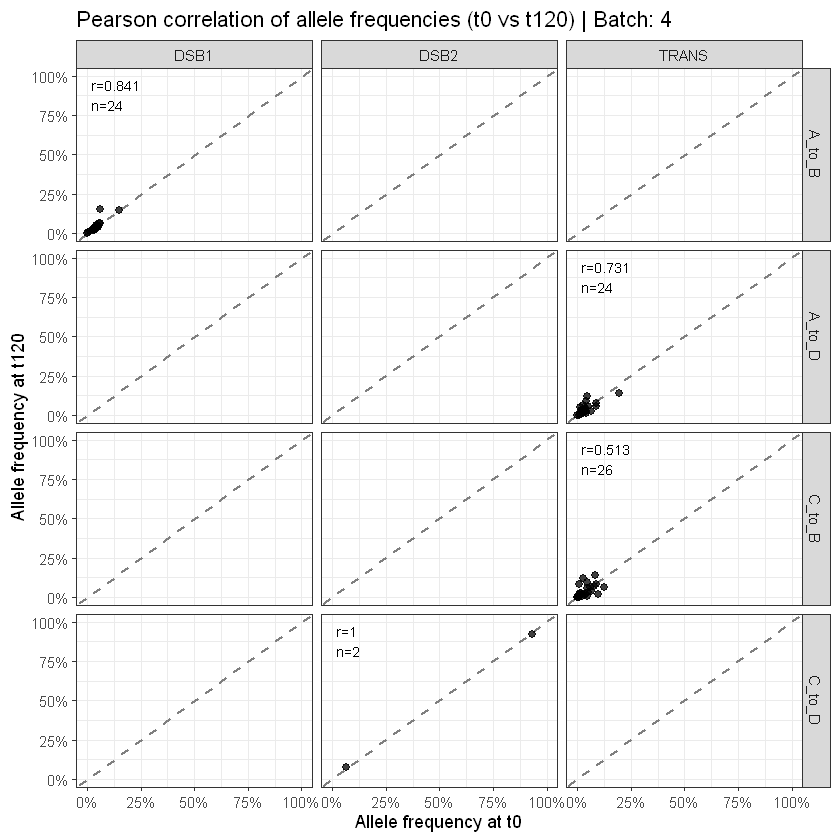

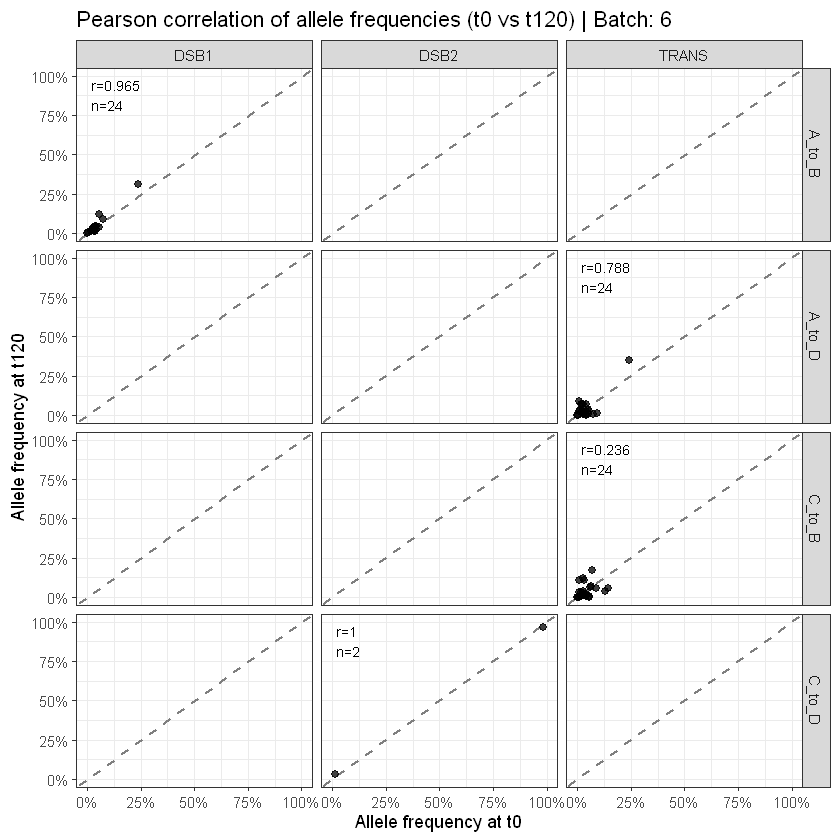

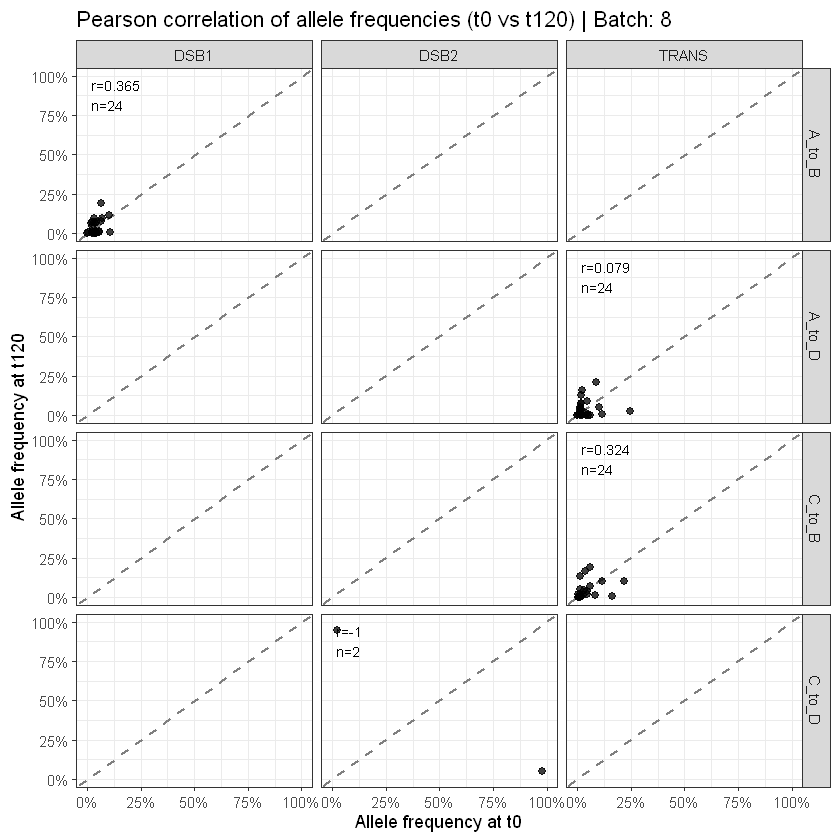

batch,DSB,cor_CIS_AF,cor_TRANS_AF,n_obs
<chr>,<chr>,<dbl>,<dbl>,<int>
4,DSB1,0.7281266,NA,24
4,DSB2,-1.0000000,NA,2
4,TRANS,NA,0.3208282,26
6,DSB1,0.4087059,NA,24
6,DSB2,-1.0000000,NA,2
6,TRANS,NA,0.4852722,24
8,DSB1,0.6913647,NA,24
8,DSB2,1.0000000,NA,2
8,TRANS,NA,0.6118651,24


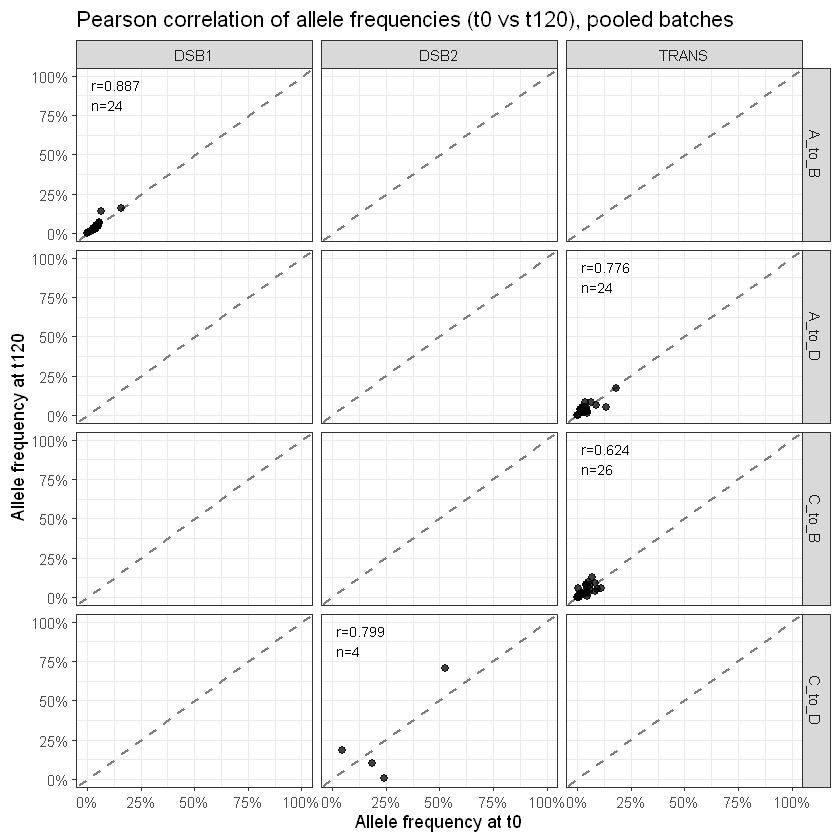

In [13]:
# ---- Sections 4.1, 5, 6: AF correlations + fold-change + summary correlation table ----
# Allele frequency (CIS + TRANS) per group
my_summarize_allelefreq <- function(dat) {
  by_allele <- dat %>%
    group_by(batch, time_point, DSB, allele) %>%
    summarise(
      Cis_Counts = sum(count[combo %in% cis_combos], na.rm = TRUE),
      Trans_Counts = sum(count[combo %in% trans_combos], na.rm = TRUE),
      Allele_Total = Cis_Counts + Trans_Counts,
      .groups = 'drop'
    )

  totals <- by_allele %>%
    group_by(batch, time_point, DSB) %>%
    summarise(
      Total_Cis = sum(Cis_Counts, na.rm = TRUE),
      Total_Trans = sum(Trans_Counts, na.rm = TRUE),
      Total_All = Total_Cis + Total_Trans,
      .groups = 'drop'
    )

  by_allele %>%
    left_join(totals, by = c('batch', 'time_point', 'DSB')) %>%
    mutate(Allele_Frequency = if_else(Total_All > 0, Allele_Total / Total_All, NA_real_))
}

safe_cor <- function(x, y) {
  idx <- is.finite(x) & is.finite(y)
  if (sum(idx) < 2) return(NA_real_)
  suppressWarnings(cor(x[idx], y[idx], method = 'pearson'))
}

dat_allele_freq <- my_summarize_allelefreq(dat_focus)

# 4.1 Pearson correlation of allele frequencies t0 vs t120
timepoints_compare <- c(0, 120)

dat_allele_freq_combo <- dat_focus %>%
  group_by(batch, DSB, combo, time_point, allele) %>%
  summarise(Allele_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(batch, DSB, combo, time_point) %>%
  mutate(
    Total_Counts = sum(Allele_Counts, na.rm = TRUE),
    Allele_Frequency = if_else(Total_Counts > 0, Allele_Counts / Total_Counts, NA_real_)
  ) %>%
  ungroup() %>%
  filter(time_point %in% timepoints_compare)

dat_wide_af <- dat_allele_freq_combo %>%
  select(batch, DSB, combo, allele, time_point, Allele_Frequency) %>%
  mutate(tp = paste0('t', time_point)) %>%
  select(-time_point) %>%
  pivot_wider(names_from = tp, values_from = Allele_Frequency)

cor_stats <- dat_wide_af %>%
  group_by(batch, DSB, combo) %>%
  summarise(
    n_pairs = sum(is.finite(t0) & is.finite(t120)),
    r = safe_cor(t0, t120),
    .groups = 'drop'
  ) %>%
  mutate(label = if_else(is.na(r), paste0('n=', n_pairs), paste0('r=', round(r, 3), '\n', 'n=', n_pairs)))

plot_cor_by_batch <- function(df_wide, df_stats) {
  batches <- df_wide %>% distinct(batch) %>% arrange(batch) %>% pull(batch)
  for (b in batches) {
    dfb <- df_wide %>% filter(batch == b)
    if (nrow(dfb) == 0) next

    statsb <- df_stats %>% filter(batch == b) %>% mutate(x = 0.02, y = 0.98)

    p <- ggplot(dfb, aes(x = t0, y = t120)) +
      geom_abline(slope = 1, intercept = 0, linewidth = 0.7, linetype = 'dashed', color = 'grey50') +
      geom_point(alpha = 0.75, size = 1.8) +
      facet_grid(combo ~ DSB) +
      geom_text(data = statsb, aes(x = x, y = y, label = label), inherit.aes = FALSE, hjust = 0, vjust = 1, size = 3) +
      scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
      scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
      theme_bw(base_size = 11) +
      labs(title = paste0('Pearson correlation of allele frequencies (t0 vs t120) | Batch: ', b), x = 'Allele frequency at t0', y = 'Allele frequency at t120')
    print(p)
  }
}

if (nrow(dat_wide_af) > 0) plot_cor_by_batch(dat_wide_af, cor_stats)

# Pooled across batches
dat_allele_freq_combo_overall <- dat_focus %>%
  group_by(DSB, combo, time_point, allele) %>%
  summarise(Allele_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, combo, time_point) %>%
  mutate(
    Total_Counts = sum(Allele_Counts, na.rm = TRUE),
    Allele_Frequency = if_else(Total_Counts > 0, Allele_Counts / Total_Counts, NA_real_)
  ) %>%
  ungroup() %>%
  filter(time_point %in% timepoints_compare)

dat_wide_overall <- dat_allele_freq_combo_overall %>%
  select(DSB, combo, allele, time_point, Allele_Frequency) %>%
  mutate(tp = paste0('t', time_point)) %>%
  select(-time_point) %>%
  pivot_wider(names_from = tp, values_from = Allele_Frequency)

cor_stats_overall <- dat_wide_overall %>%
  group_by(DSB, combo) %>%
  summarise(
    n_pairs = sum(is.finite(t0) & is.finite(t120)),
    r = safe_cor(t0, t120),
    .groups = 'drop'
  ) %>%
  mutate(
    label = if_else(is.na(r), paste0('n=', n_pairs), paste0('r=', round(r, 3), '\n', 'n=', n_pairs)),
    x = 0.02,
    y = 0.98
  )

if (nrow(dat_wide_overall) > 0) {
  p_overall_af_corr <- ggplot(dat_wide_overall, aes(x = t0, y = t120)) +
    geom_abline(slope = 1, intercept = 0, linewidth = 0.7, linetype = 'dashed', color = 'grey50') +
    geom_point(alpha = 0.75, size = 1.8) +
    facet_grid(combo ~ DSB) +
    geom_text(data = cor_stats_overall, aes(x = x, y = y, label = label), inherit.aes = FALSE, hjust = 0, vjust = 1, size = 3) +
    scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    theme_bw(base_size = 11) +
    labs(title = 'Pearson correlation of allele frequencies (t0 vs t120), pooled batches', x = 'Allele frequency at t0', y = 'Allele frequency at t120')
  print(p_overall_af_corr)
}

# Section 5: Fold-change calculations (120 / 0)
eps <- 1e-6

dat_fc_cis <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, time_point, DSB, allele, Cis_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = Cis_Location_Counts, values_fill = 0) %>%
  mutate(
    FoldChange_Cis_120_vs_0 = fc_ratio(`120`, `0`, eps = eps),
    Log2FC_Cis_120_vs_0 = log2(FoldChange_Cis_120_vs_0)
  )

dat_fc_trans <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, time_point, DSB, allele, Trans_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = Trans_Location_Counts, values_fill = 0) %>%
  mutate(
    FoldChange_Trans_120_vs_0 = fc_ratio(`120`, `0`, eps = eps),
    Log2FC_Trans_120_vs_0 = log2(FoldChange_Trans_120_vs_0)
  )

# Section 6: Correlation of log2FC vs AF
dat_wide <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, DSB, allele, time_point, Cis_Location_Counts, Trans_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = c(Cis_Location_Counts, Trans_Location_Counts), values_fill = 0) %>%
  mutate(
    log2FC_CIS = log2(fc_ratio(Cis_Location_Counts_120, Cis_Location_Counts_0, eps = eps)),
    log2FC_TRANS = log2(fc_ratio(Trans_Location_Counts_120, Trans_Location_Counts_0, eps = eps))
  )

dat_fc_af <- dat_wide %>%
  inner_join(
    dat_allele_freq %>% filter(time_point == 120) %>% select(batch, DSB, allele, Allele_Frequency),
    by = c('batch', 'DSB', 'allele')
  ) %>%
  filter(!is.na(Allele_Frequency) & Allele_Frequency > 0)

cor_summary <- dat_fc_af %>%
  group_by(batch, DSB) %>%
  summarise(
    cor_CIS_AF = safe_cor(log2FC_CIS, Allele_Frequency),
    cor_TRANS_AF = safe_cor(log2FC_TRANS, Allele_Frequency),
    n_obs = n(),
    .groups = 'drop'
  )

cor_summary

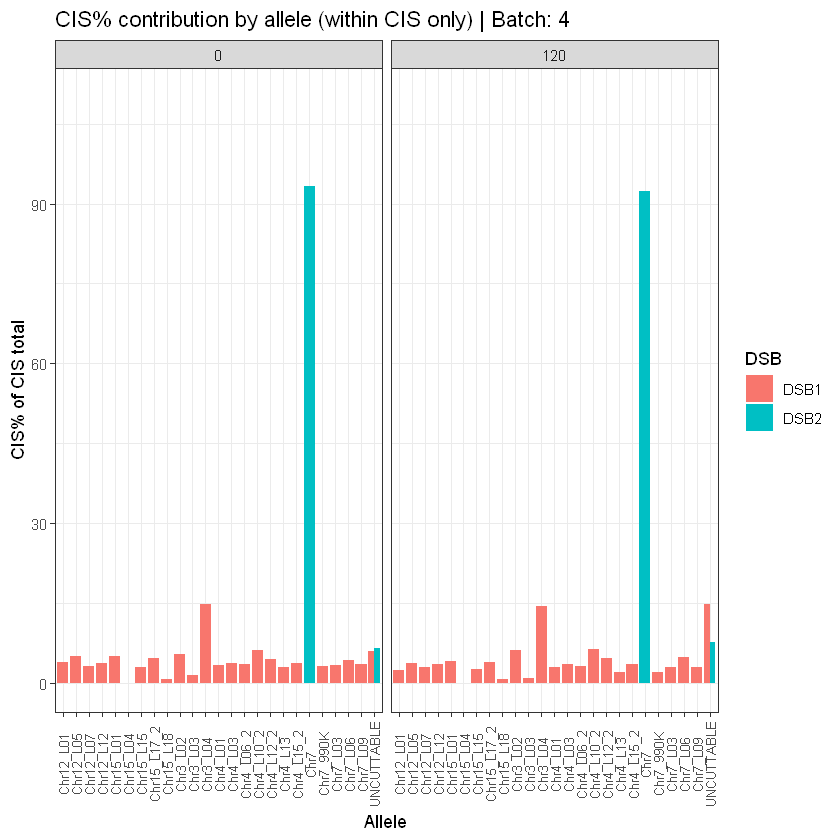

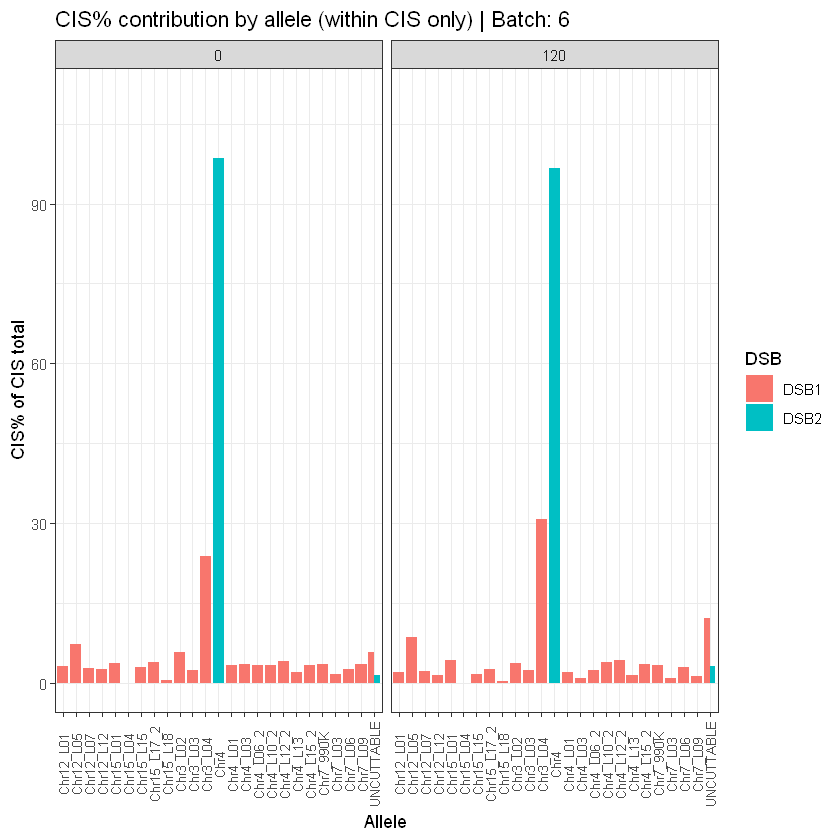

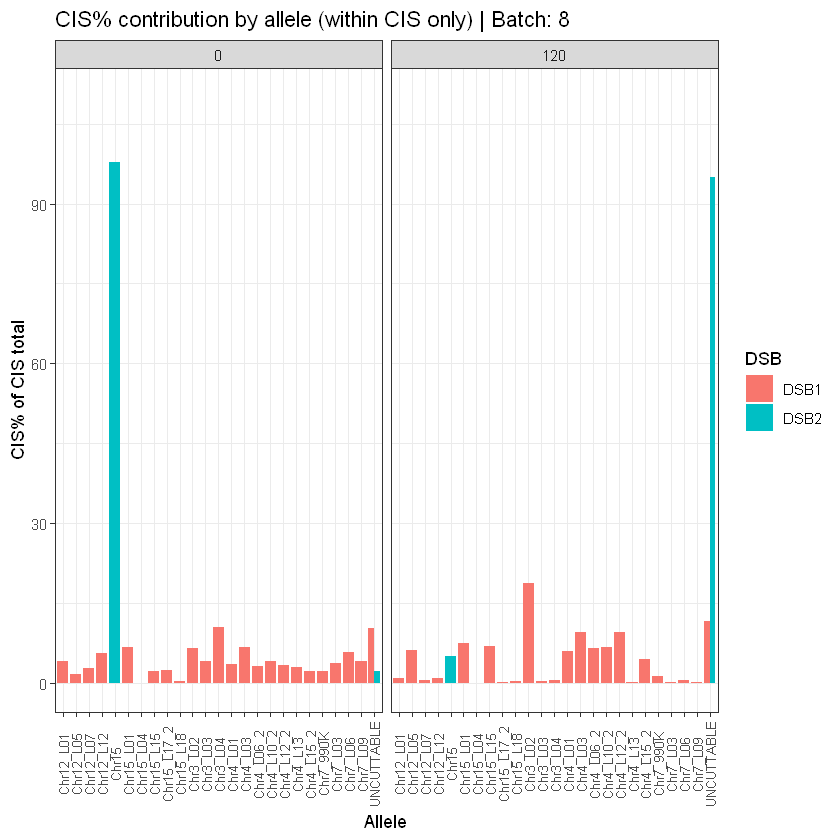

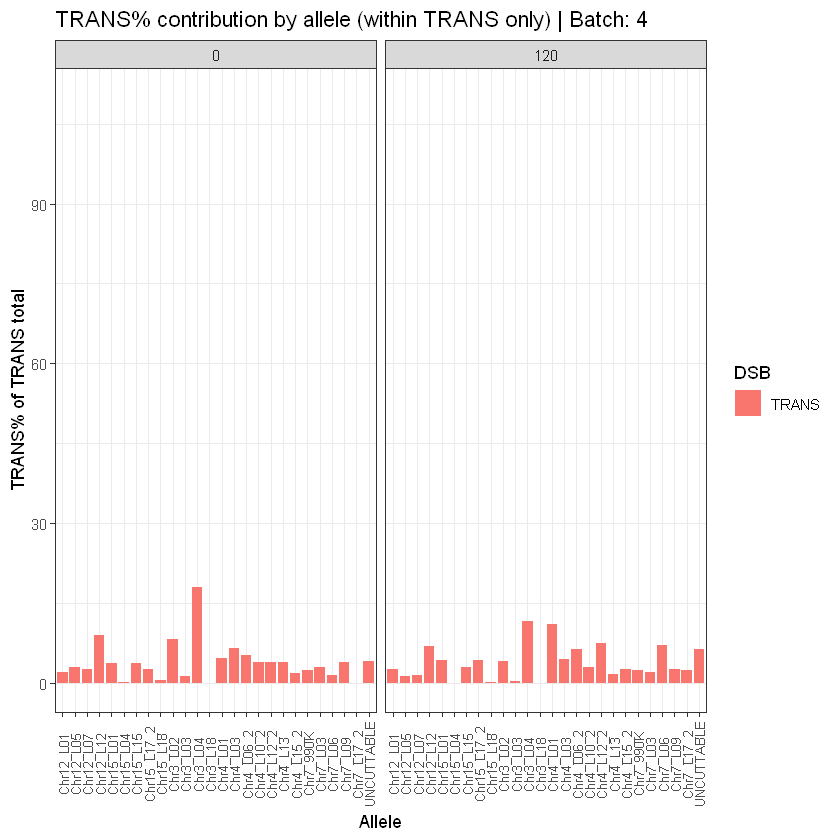

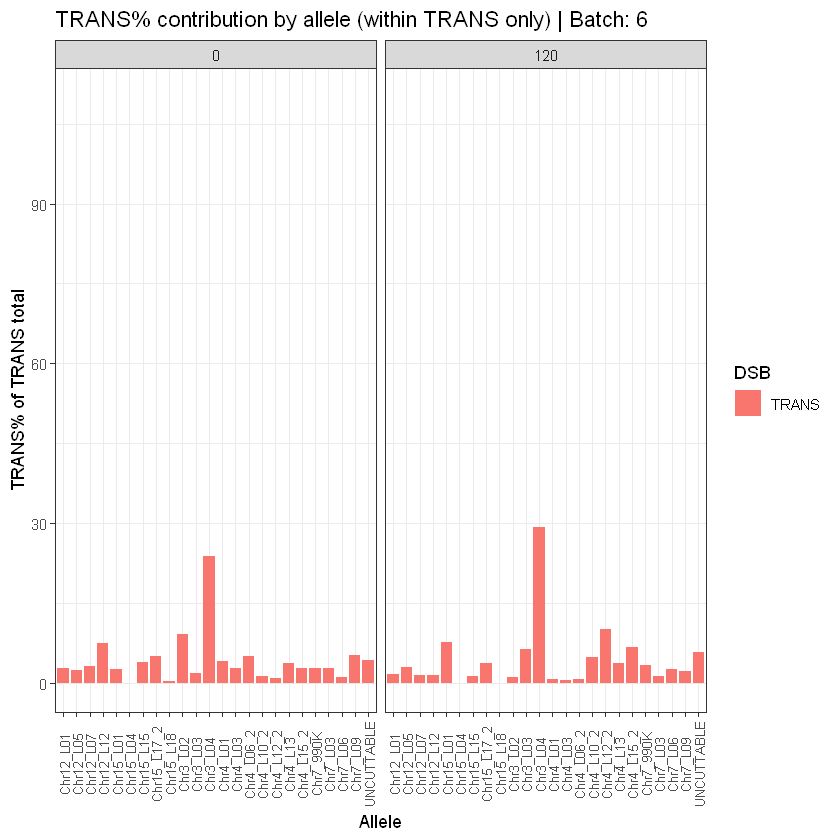

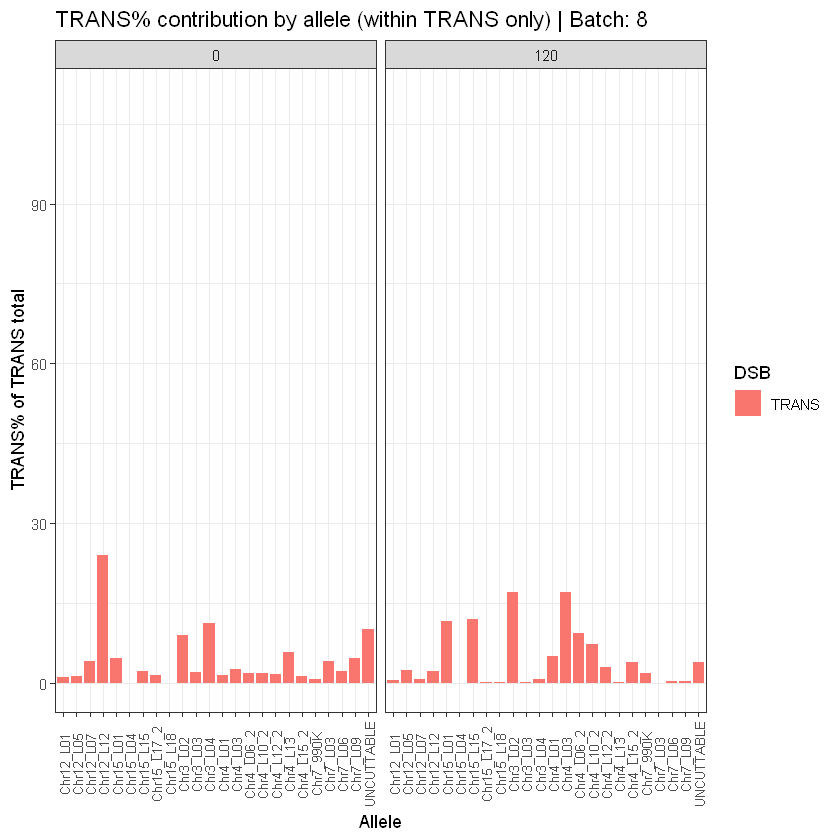

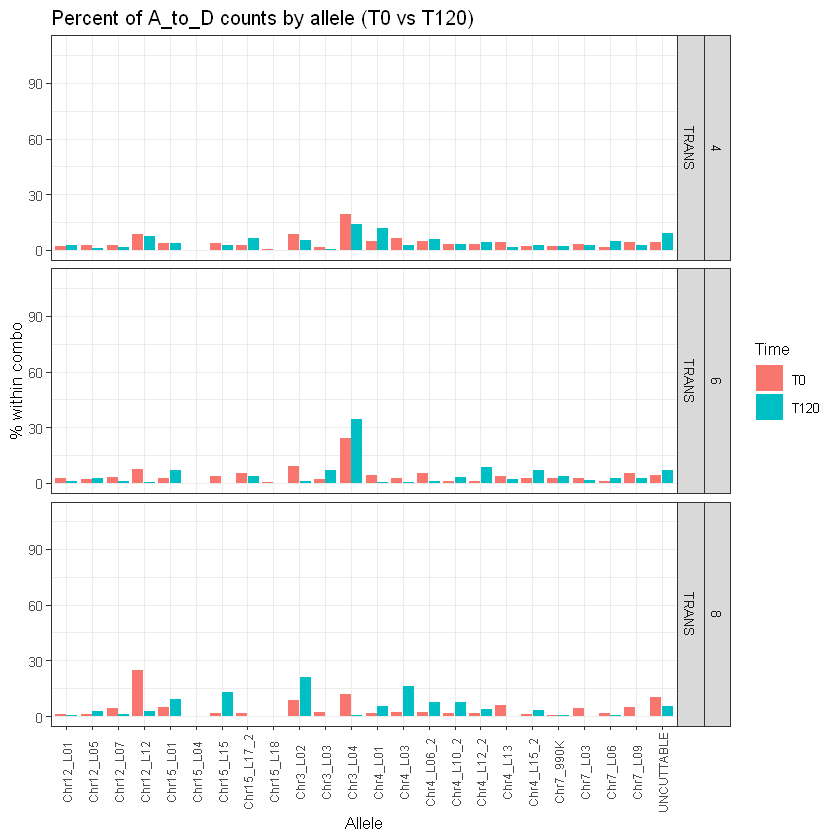

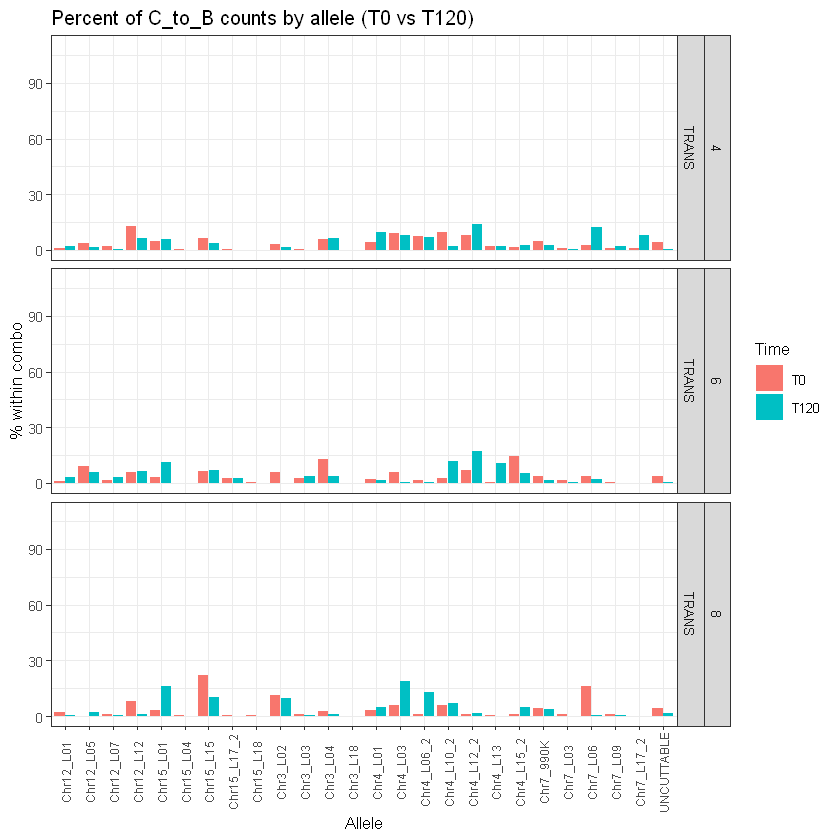

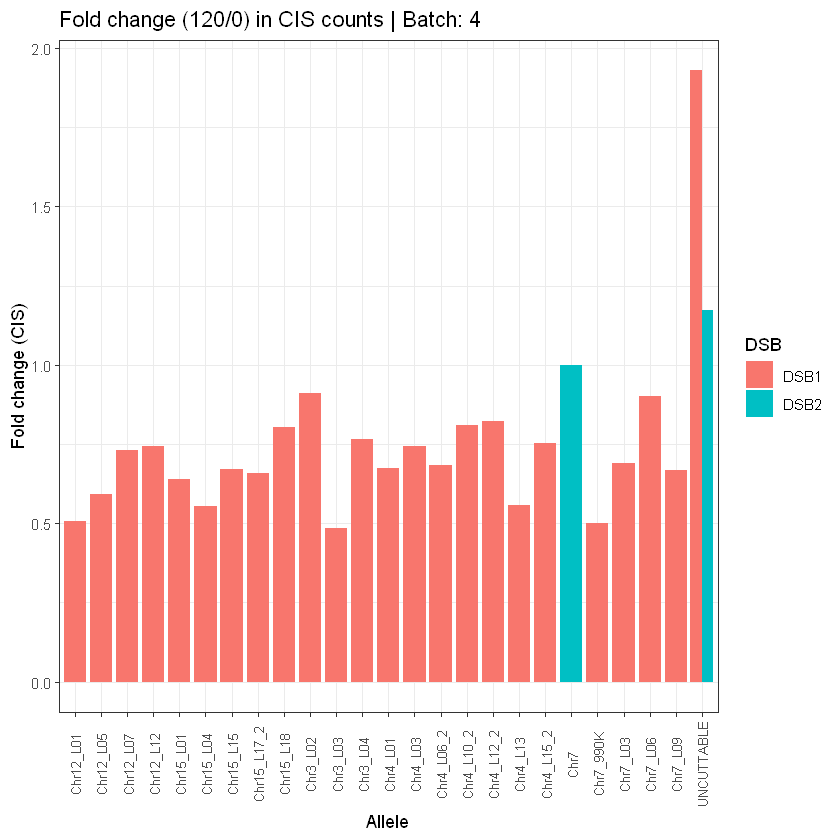

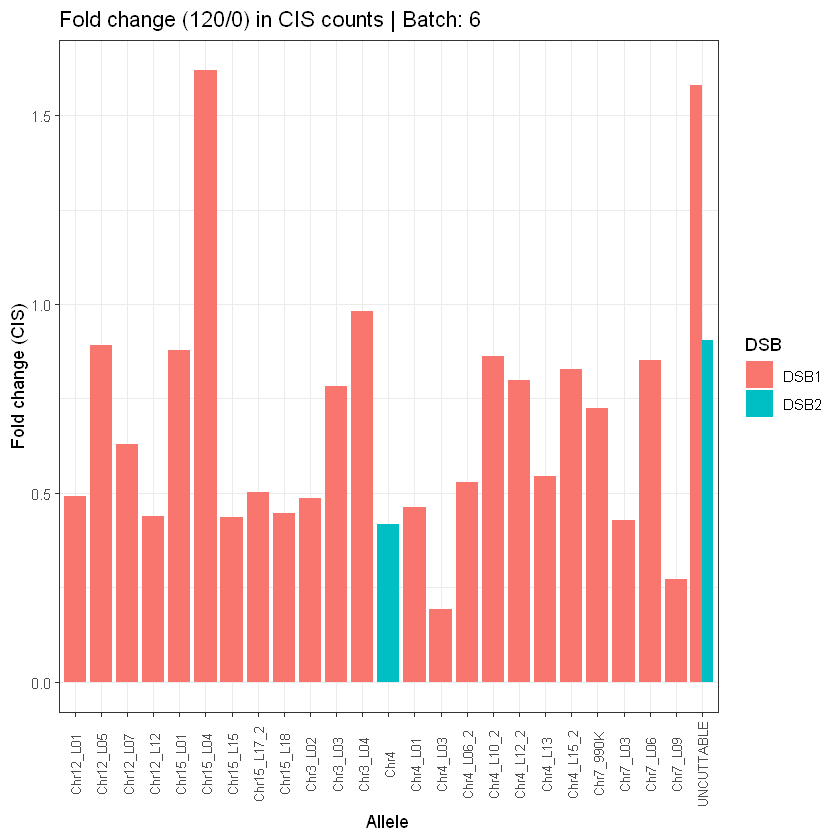

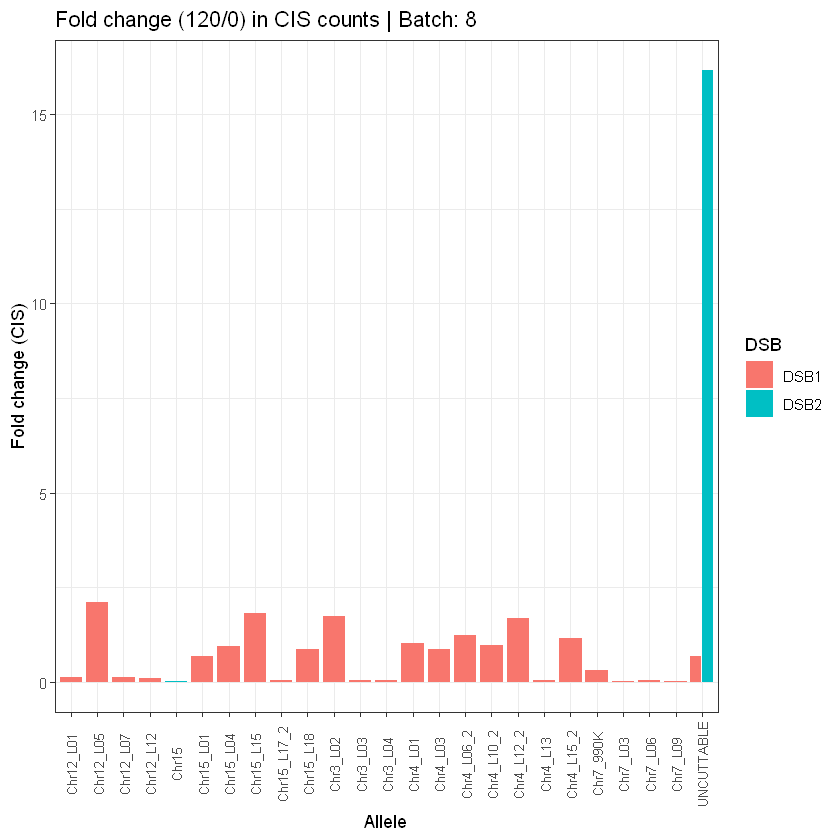

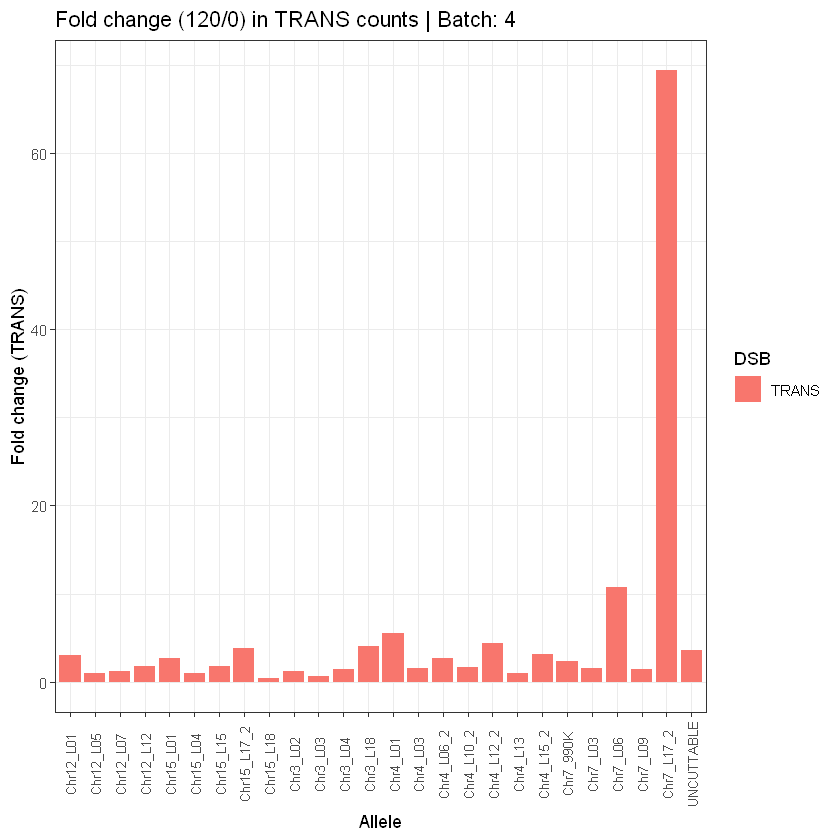

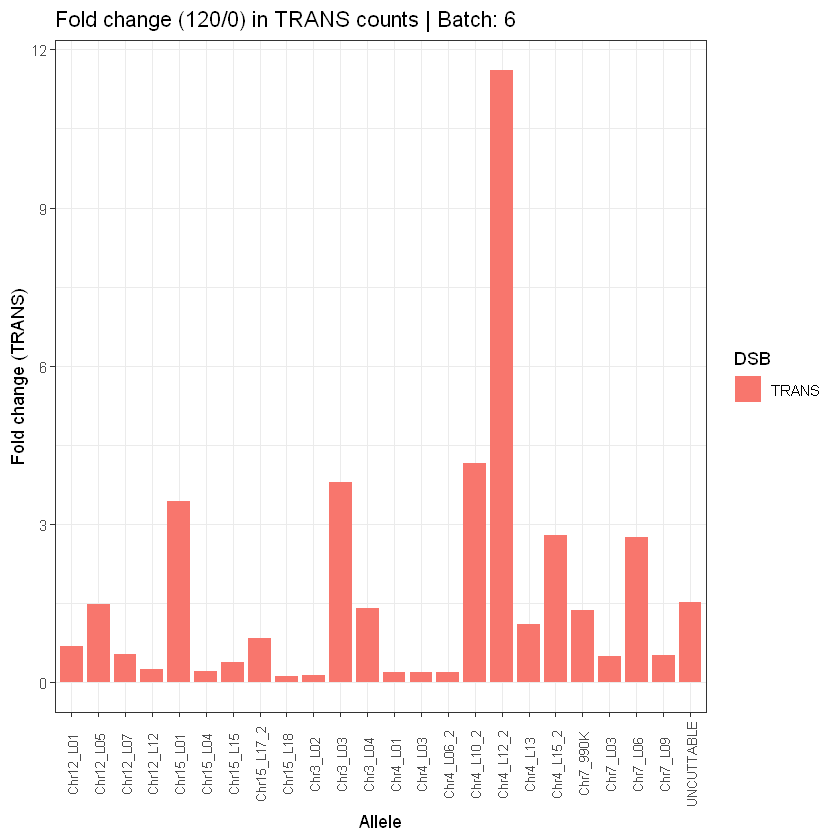

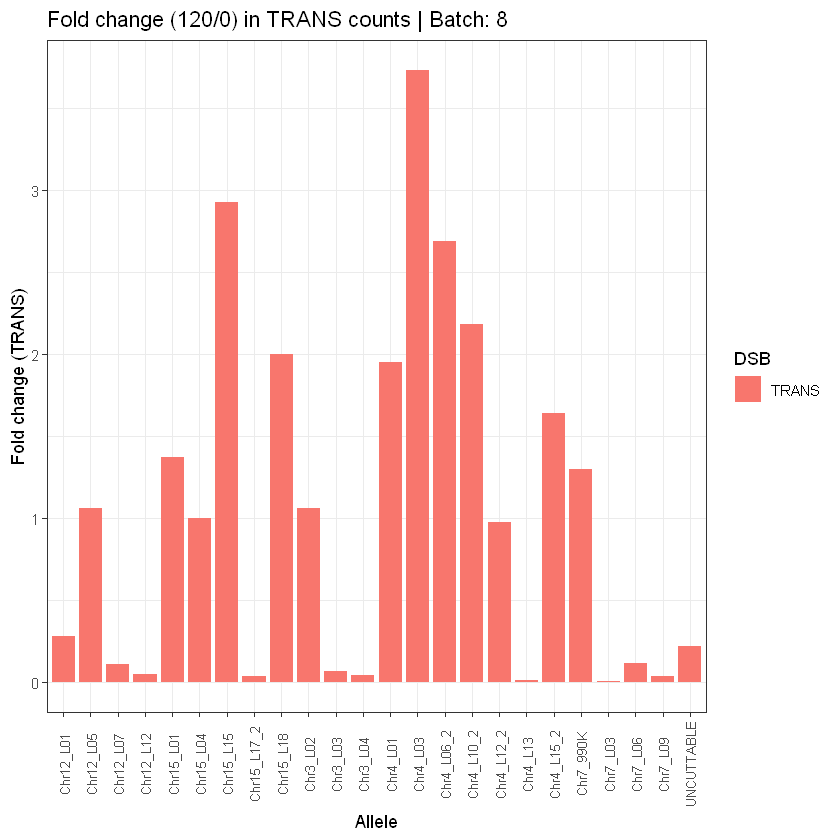

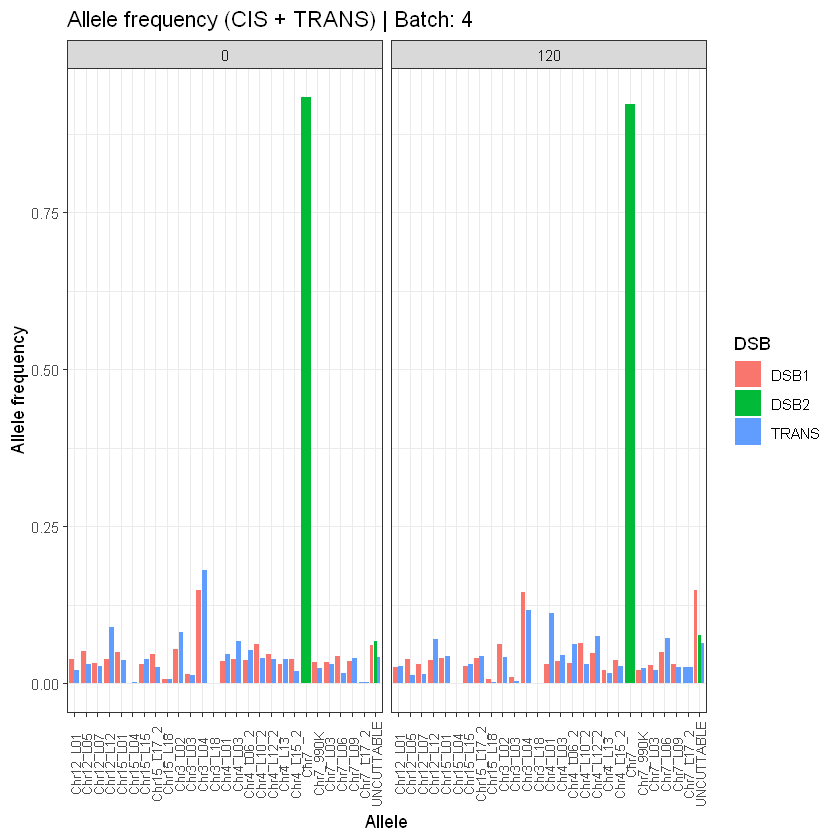

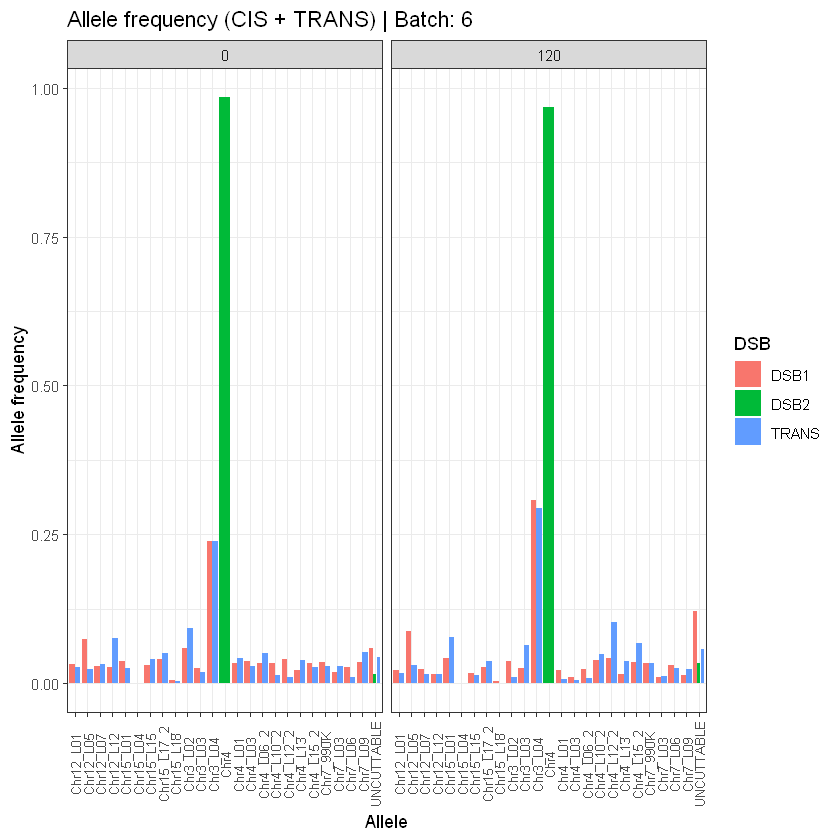

`geom_smooth()` using formula = 'y ~ x'


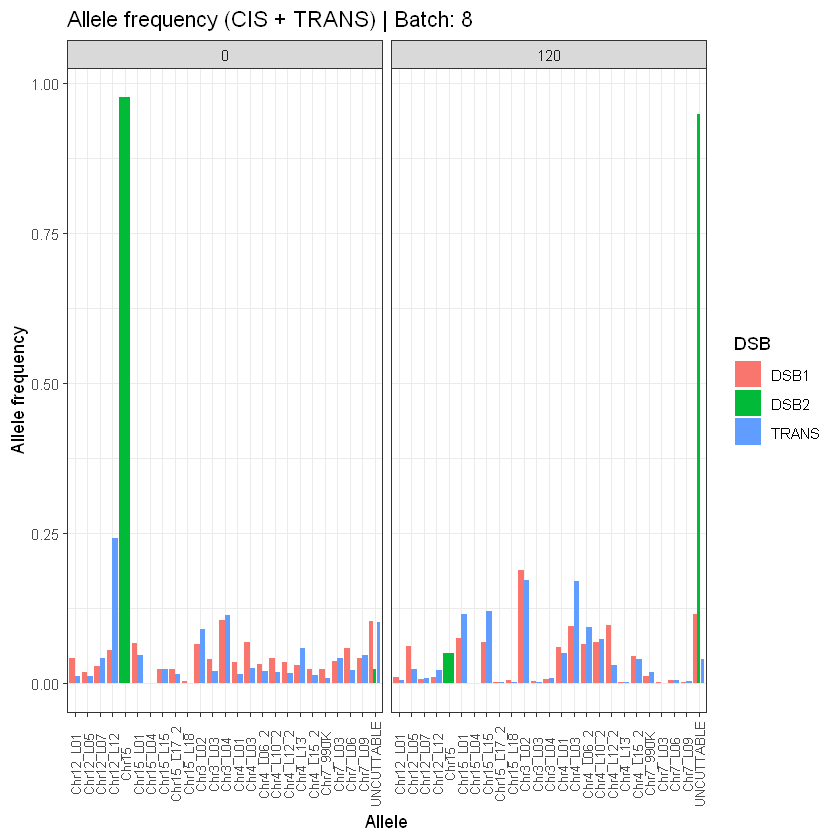

`geom_smooth()` using formula = 'y ~ x'


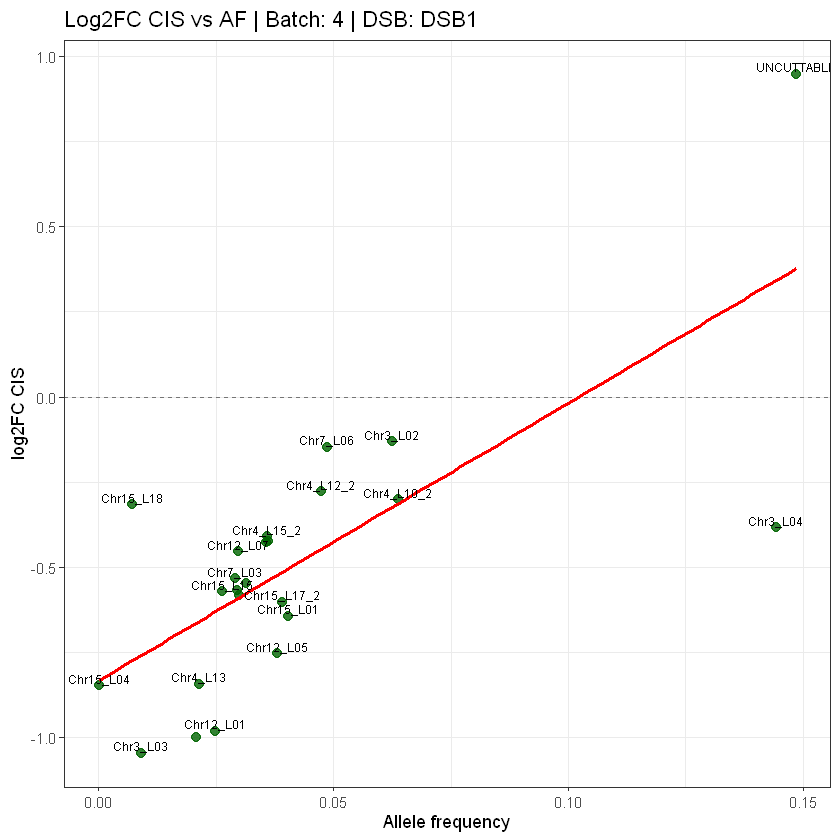

`geom_smooth()` using formula = 'y ~ x'


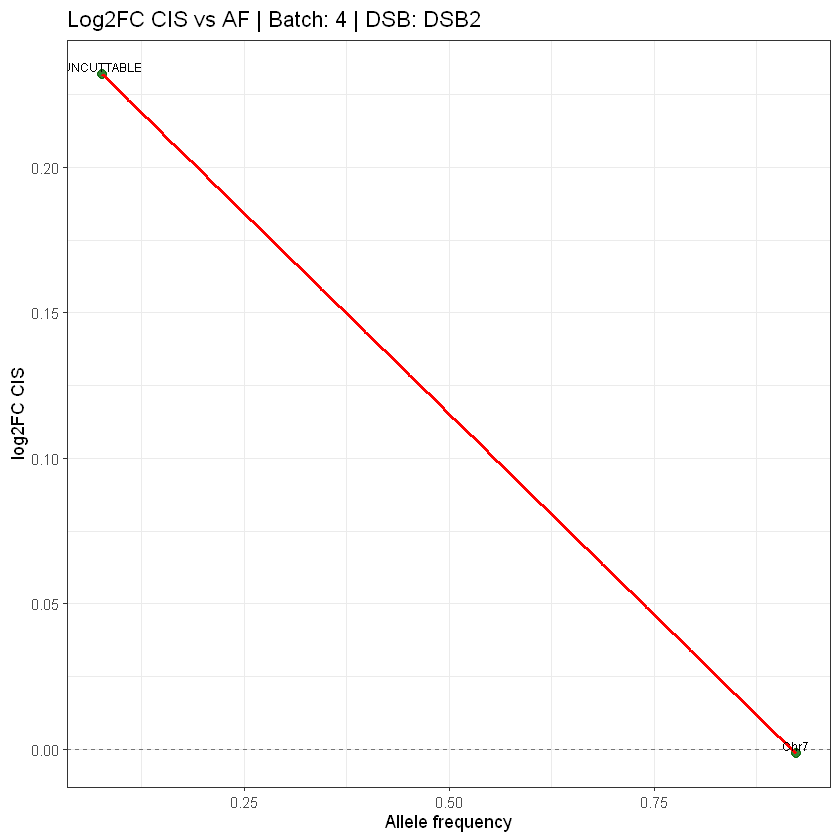

`geom_smooth()` using formula = 'y ~ x'


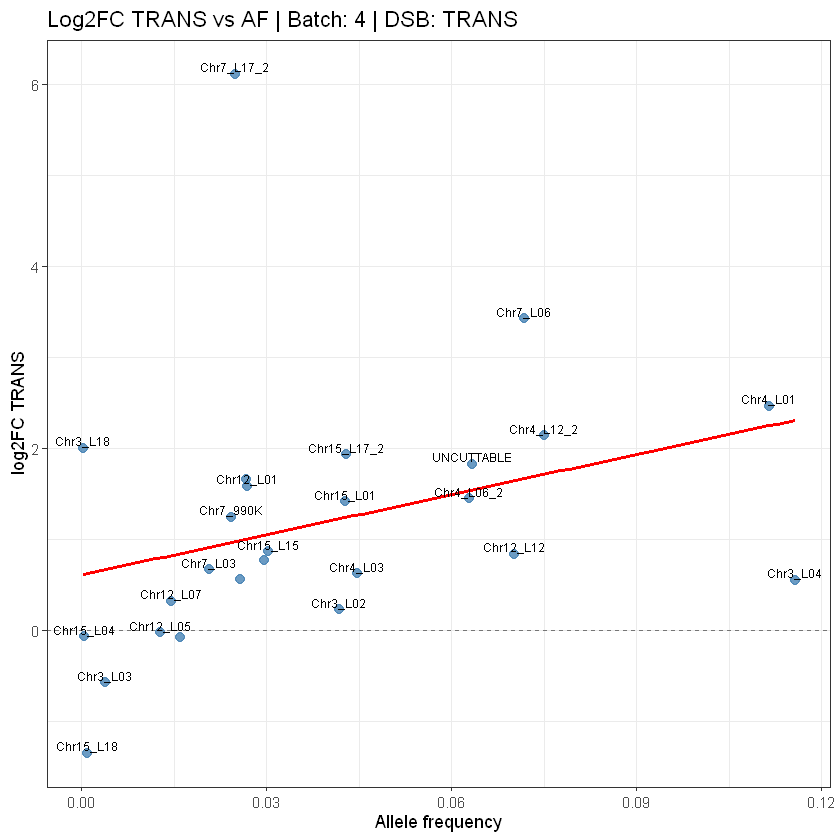

`geom_smooth()` using formula = 'y ~ x'


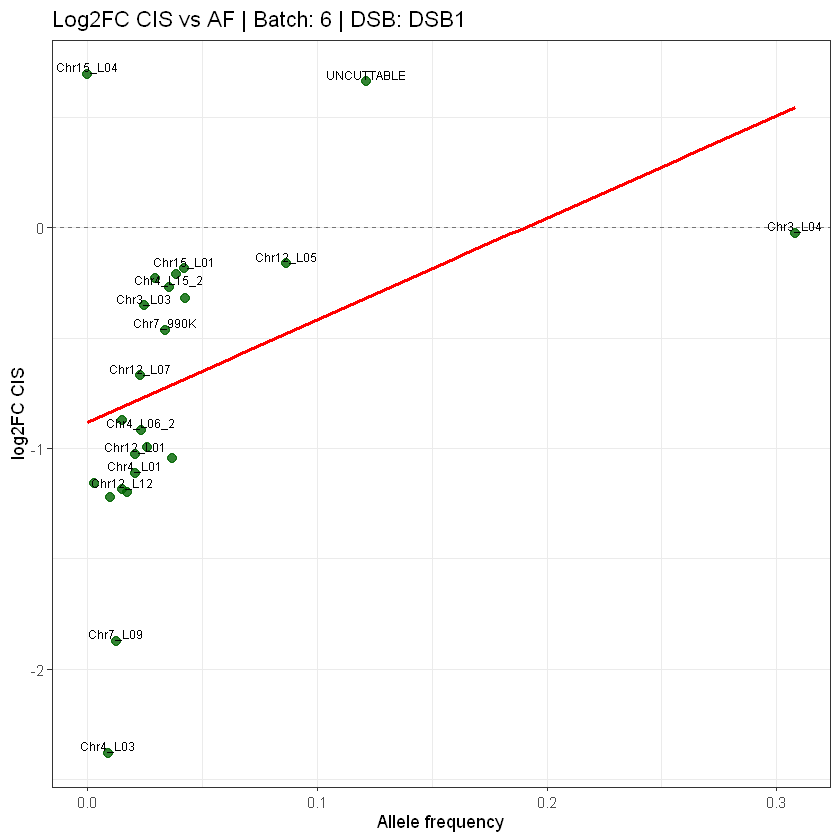

`geom_smooth()` using formula = 'y ~ x'


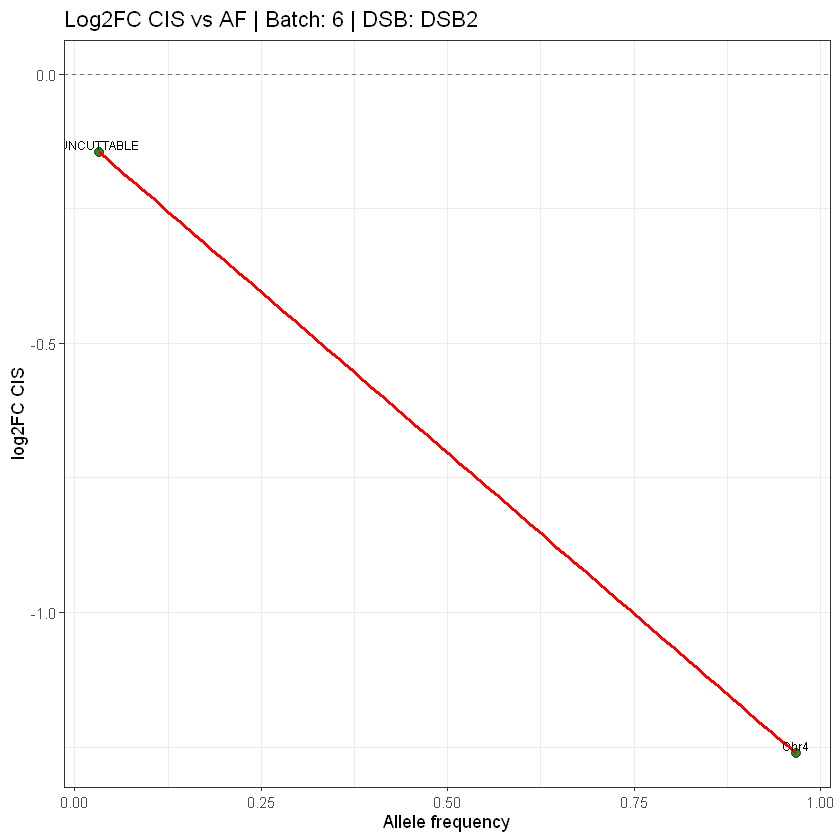

`geom_smooth()` using formula = 'y ~ x'


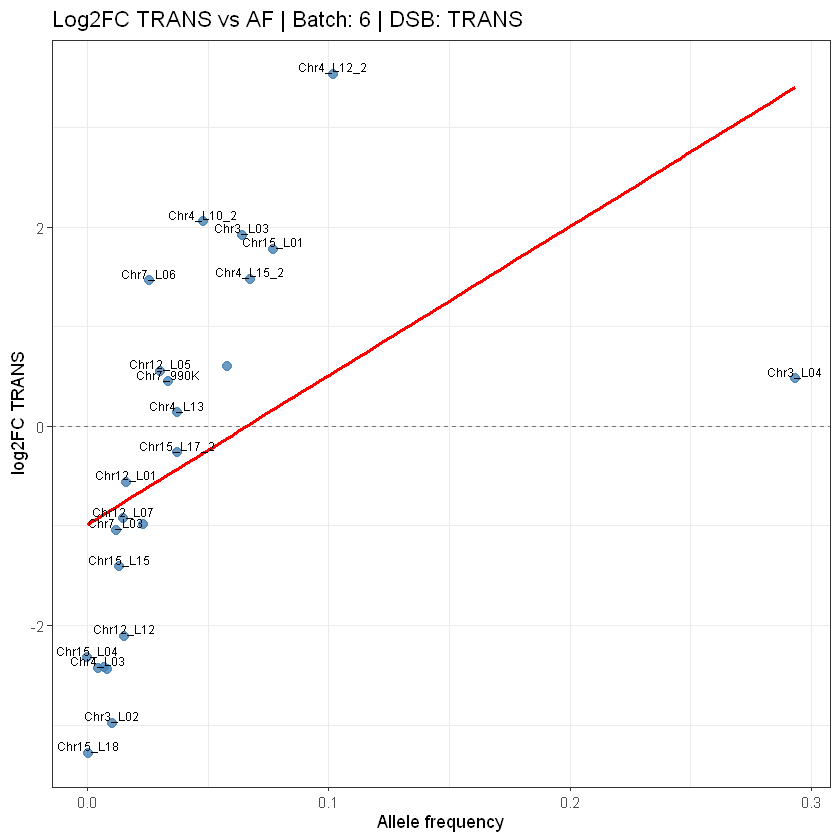

`geom_smooth()` using formula = 'y ~ x'


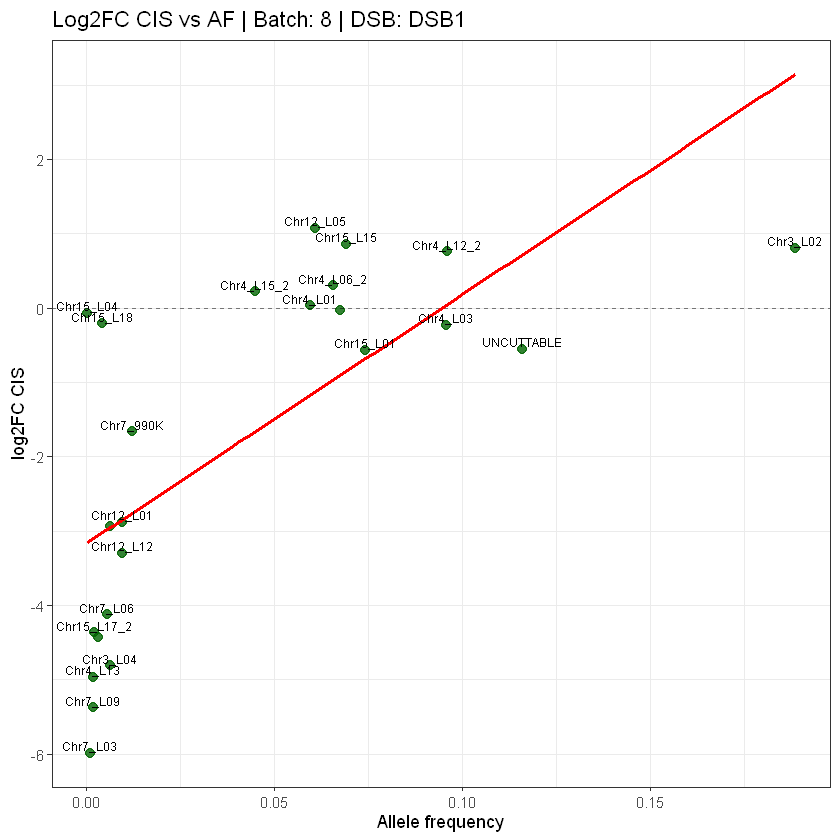

`geom_smooth()` using formula = 'y ~ x'


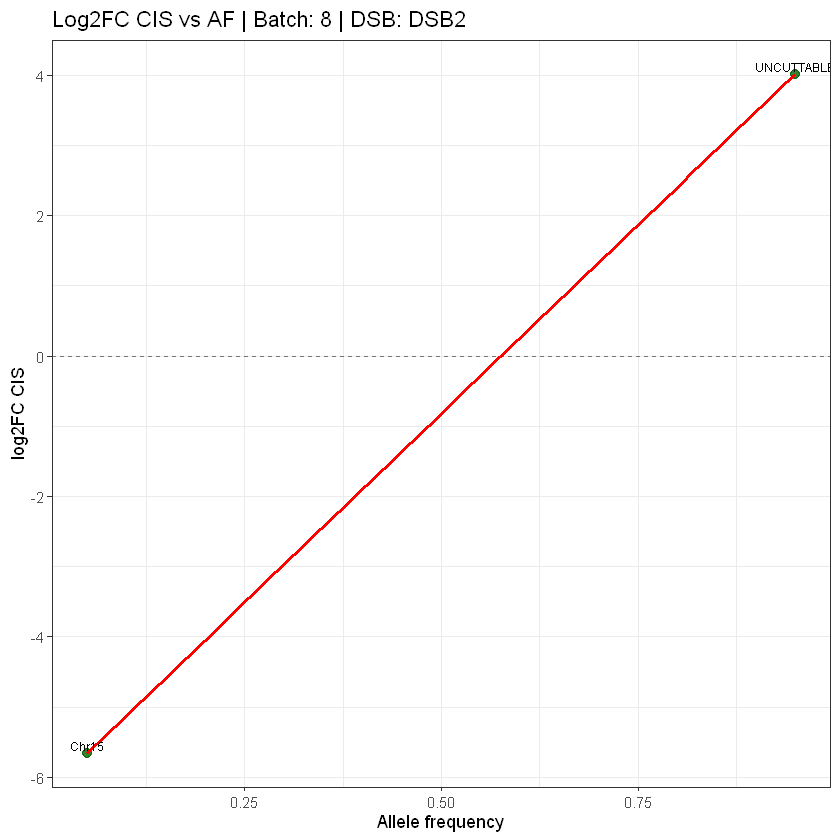

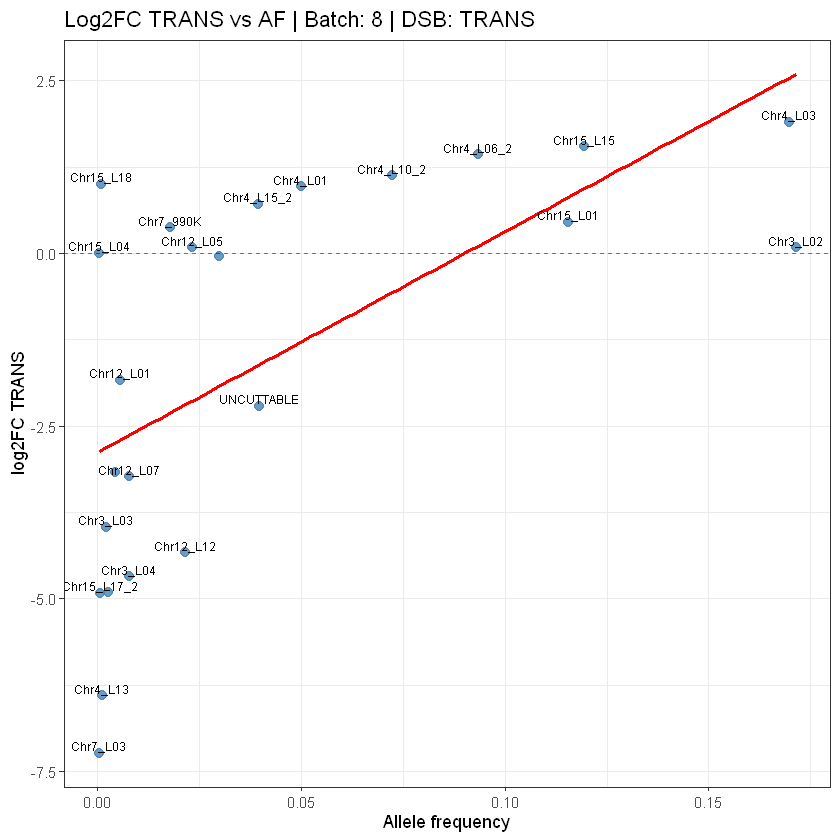

In [17]:
# ---- Sections 7, 8, 9: contribution bars, FC bars, and log2FC-vs-AF scatters (cleaned) ----
plot_cis_contrib_by_batch <- function(df_cis_dist) {
  batches <- df_cis_dist %>% distinct(batch) %>% arrange(batch) %>% pull(batch)
  for (b in batches) {
    df_plot <- df_cis_dist %>%
      filter(batch == b, is.finite(Percent_Location_in_Cis))
    if (nrow(df_plot) == 0) next

    p <- ggplot(df_plot, aes(x = allele, y = Percent_Location_in_Cis, fill = DSB)) +
      geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
      facet_wrap(~ time_point, scales = 'free_x') +
      coord_cartesian(ylim = c(0, 110)) +
      theme_bw(base_size = 11) +
      theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
      labs(
        title = paste0('CIS% contribution by allele (within CIS only) | Batch: ', b),
        x = 'Allele', y = 'CIS% of CIS total', fill = 'DSB'
      )
    print(p)
  }
}

plot_trans_contrib_by_batch <- function(df_trans_dist) {
  batches <- df_trans_dist %>% distinct(batch) %>% arrange(batch) %>% pull(batch)
  for (b in batches) {
    df_plot <- df_trans_dist %>%
      filter(batch == b, is.finite(Percent_Location_in_Trans))
    if (nrow(df_plot) == 0) next

    p <- ggplot(df_plot, aes(x = allele, y = Percent_Location_in_Trans, fill = DSB)) +
      geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
      facet_wrap(~ time_point, scales = 'free_x') +
      coord_cartesian(ylim = c(0, 110)) +
      theme_bw(base_size = 11) +
      theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
      labs(
        title = paste0('TRANS% contribution by allele (within TRANS only) | Batch: ', b),
        x = 'Allele', y = 'TRANS% of TRANS total', fill = 'DSB'
      )
    print(p)
  }
}

plot_trans_percent_by_combo <- function(dat, combo_name) {
  df_plot <- dat %>%
    filter(combo == combo_name, time_point %in% c(0, 120)) %>%
    group_by(batch, time_point, DSB, allele) %>%
    summarise(Trans_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
    group_by(batch, time_point, DSB) %>%
    mutate(
      Total_Trans = sum(Trans_Counts, na.rm = TRUE),
      Percent_Trans = if_else(Total_Trans > 0, 100 * Trans_Counts / Total_Trans, NA_real_)
    ) %>%
    ungroup() %>%
    filter(is.finite(Percent_Trans))

  if (nrow(df_plot) == 0) return(NULL)

  ggplot(df_plot, aes(x = allele, y = Percent_Trans, fill = factor(time_point, levels = c(0, 120), labels = c('T0', 'T120')))) +
    geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
    facet_grid(batch + DSB ~ ., scales = 'free_x') +
    coord_cartesian(ylim = c(0, 110)) +
    theme_bw(base_size = 10) +
    theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 7)) +
    labs(title = paste('Percent of', combo_name, 'counts by allele (T0 vs T120)'), x = 'Allele', y = '% within combo', fill = 'Time')
}

plot_foldchange_cis_by_batch <- function(df_fc) {
  batches <- df_fc %>% distinct(batch) %>% arrange(batch) %>% pull(batch)
  for (b in batches) {
    df_plot <- df_fc %>% filter(batch == b, is.finite(FoldChange_Cis_120_vs_0))
    if (nrow(df_plot) == 0) next

    p <- ggplot(df_plot, aes(x = allele, y = FoldChange_Cis_120_vs_0, fill = DSB)) +
      geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
      theme_bw(base_size = 11) +
      theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
      labs(title = paste0('Fold change (120/0) in CIS counts | Batch: ', b), x = 'Allele', y = 'Fold change (CIS)', fill = 'DSB')
    print(p)
  }
}

plot_foldchange_trans_by_batch <- function(df_fc) {
  batches <- df_fc %>% distinct(batch) %>% arrange(batch) %>% pull(batch)
  for (b in batches) {
    df_plot <- df_fc %>% filter(batch == b, is.finite(FoldChange_Trans_120_vs_0))
    if (nrow(df_plot) == 0) next

    p <- ggplot(df_plot, aes(x = allele, y = FoldChange_Trans_120_vs_0, fill = DSB)) +
      geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
      theme_bw(base_size = 11) +
      theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
      labs(title = paste0('Fold change (120/0) in TRANS counts | Batch: ', b), x = 'Allele', y = 'Fold change (TRANS)', fill = 'DSB')
    print(p)
  }
}

plot_allele_frequency_by_batch <- function(df_af) {
  batches <- df_af %>% distinct(batch) %>% arrange(batch) %>% pull(batch)
  for (b in batches) {
    df_plot <- df_af %>% filter(batch == b, is.finite(Allele_Frequency))
    if (nrow(df_plot) == 0) next

    p <- ggplot(df_plot, aes(x = allele, y = Allele_Frequency, fill = DSB)) +
      geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
      facet_wrap(~ time_point, scales = 'free_x') +
      theme_bw(base_size = 11) +
      theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
      labs(title = paste0('Allele frequency (CIS + TRANS) | Batch: ', b), x = 'Allele', y = 'Allele frequency', fill = 'DSB')
    print(p)
  }
}

plot_correlation_cis <- function(df, batch_name, dsb_name) {
  df_plot <- df %>%
    filter(batch == batch_name, DSB == dsb_name) %>%
    mutate(valid = is.finite(Allele_Frequency) & is.finite(log2FC_CIS)) %>%
    filter(valid)

  if (nrow(df_plot) < 2) return(NULL)

  p <- ggplot(df_plot, aes(x = Allele_Frequency, y = log2FC_CIS)) +
    geom_point(size = 2.4, alpha = 0.8, color = 'darkgreen') +
    geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
    geom_smooth(aes(x = Allele_Frequency, y = log2FC_CIS), method = 'lm', se = FALSE, color = 'red', inherit.aes = FALSE) +
    theme_bw(base_size = 11) +
    labs(title = paste0('Log2FC CIS vs AF | Batch: ', batch_name, ' | DSB: ', dsb_name), x = 'Allele frequency', y = 'log2FC CIS')

  if (has_ggrepel) {
    p <- p + ggrepel::geom_text_repel(aes(label = allele), size = 2.7, max.overlaps = 20)
  } else {
    p <- p + geom_text(aes(label = allele), size = 2.6, check_overlap = TRUE, vjust = -0.25)
  }
  p
}

plot_correlation_trans <- function(df, batch_name, dsb_name) {
  df_plot <- df %>%
    filter(batch == batch_name, DSB == dsb_name) %>%
    mutate(valid = is.finite(Allele_Frequency) & is.finite(log2FC_TRANS)) %>%
    filter(valid)

  if (nrow(df_plot) < 2) return(NULL)

  p <- ggplot(df_plot, aes(x = Allele_Frequency, y = log2FC_TRANS)) +
    geom_point(size = 2.4, alpha = 0.8, color = 'steelblue') +
    geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
    geom_smooth(aes(x = Allele_Frequency, y = log2FC_TRANS), method = 'lm', se = FALSE, color = 'red', inherit.aes = FALSE) +
    theme_bw(base_size = 11) +
    labs(title = paste0('Log2FC TRANS vs AF | Batch: ', batch_name, ' | DSB: ', dsb_name), x = 'Allele frequency', y = 'log2FC TRANS')

  if (has_ggrepel) {
    p <- p + ggrepel::geom_text_repel(aes(label = allele), size = 2.7, max.overlaps = 20)
  } else {
    p <- p + geom_text(aes(label = allele), size = 2.6, check_overlap = TRUE, vjust = -0.25)
  }
  p
}

# Run section 7 plots

df_cis_dist <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, time_point, DSB, allele, Percent_Location_in_Cis)

df_trans_dist <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, time_point, DSB, allele, Percent_Location_in_Trans)

plot_cis_contrib_by_batch(df_cis_dist)
plot_trans_contrib_by_batch(df_trans_dist)

p_trans_ad <- plot_trans_percent_by_combo(dat_focus, 'A_to_D')
if (!is.null(p_trans_ad)) print(p_trans_ad)

p_trans_cb <- plot_trans_percent_by_combo(dat_focus, 'C_to_B')
if (!is.null(p_trans_cb)) print(p_trans_cb)

# Run section 8 plots
plot_foldchange_cis_by_batch(dat_fc_cis)
plot_foldchange_trans_by_batch(dat_fc_trans)
plot_allele_frequency_by_batch(dat_allele_freq)

# Run section 9 plots
plot_keys <- dat_fc_af %>% distinct(batch, DSB) %>% arrange(batch, DSB)

for (i in seq_len(nrow(plot_keys))) {
  b <- plot_keys$batch[[i]]
  d <- plot_keys$DSB[[i]]
  p_cis_scatter <- plot_correlation_cis(dat_fc_af, b, d)
  p_trans_scatter <- plot_correlation_trans(dat_fc_af, b, d)
  if (!is.null(p_cis_scatter)) print(p_cis_scatter)
  if (!is.null(p_trans_scatter)) print(p_trans_scatter)
}

In [21]:
# ---- Advanced export + diagnostics ----
out_dir <- file.path(getwd(), 'Outputs', '3C')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

plot_export_list <- list(
  `3C_QC_total_counts` = p_total,
  `3C_QC_cis_trans_percent` = p_cistrans,
  `3C_group4_trans_share` = p_group4_trans_total,
  `3C_group4_cis_share` = p_group4_cis_total,
  `3C_group4_within_cis` = p_cis_comp_2only,
  `3C_group4_within_trans` = p_trans_comp_2only,
  `3C_af_corr_pooled_t0_t120` = if (exists('p_overall_af_corr')) p_overall_af_corr else NULL,
  `3C_trans_combo_A_to_D` = if (exists('p_trans_ad')) p_trans_ad else NULL,
  `3C_trans_combo_C_to_B` = if (exists('p_trans_cb')) p_trans_cb else NULL
)

for (nm in names(plot_export_list)) {
  p <- plot_export_list[[nm]]
  if (!is.null(p)) {
    ggsave(
      filename = file.path(out_dir, paste0(nm, '.png')),
      plot = p,
      width = 14,
      height = 8,
      dpi = 200
    )
  }
}

key_counts <- tibble::tibble(
  object = c('dat_raw', 'dat_focus', 'dat_norm_combo', 'dat_group4', 'dat_allele_freq', 'dat_fc_cis', 'dat_fc_trans', 'dat_fc_af', 'cor_summary'),
  n_rows = c(
    nrow(dat_raw), nrow(dat_focus), nrow(dat_norm_combo), nrow(dat_group4),
    nrow(dat_allele_freq), nrow(dat_fc_cis), nrow(dat_fc_trans), nrow(dat_fc_af), nrow(cor_summary)
  )
)

message('Saved advanced plots to: ', out_dir)
key_counts

na_diag <- tibble::tibble(
  metric = c('Log2FC_Cis_120_vs_0', 'Log2FC_Trans_120_vs_0', 'dat_fc_af$log2FC_CIS', 'dat_fc_af$log2FC_TRANS', 'dat_fc_af$Allele_Frequency'),
  na_fraction = c(
    mean(is.na(dat_fc_cis$Log2FC_Cis_120_vs_0)),
    mean(is.na(dat_fc_trans$Log2FC_Trans_120_vs_0)),
    mean(is.na(dat_fc_af$log2FC_CIS)),
    mean(is.na(dat_fc_af$log2FC_TRANS)),
    mean(is.na(dat_fc_af$Allele_Frequency))
  )
)

na_diag

Saved advanced plots to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/3C



object,n_rows
<chr>,<int>
dat_raw,596
dat_focus,596
dat_norm_combo,304
dat_group4,6
dat_allele_freq,304
dat_fc_cis,152
dat_fc_trans,152
dat_fc_af,152
cor_summary,9


metric,na_fraction
<chr>,<dbl>
Log2FC_Cis_120_vs_0,0.4868421
Log2FC_Trans_120_vs_0,0.5131579
dat_fc_af$log2FC_CIS,0.4868421
dat_fc_af$log2FC_TRANS,0.5131579
dat_fc_af$Allele_Frequency,0.0000000
